In [ ]:
import pandas as pd

df = pd.read_csv('/content/ev_charging_dataset.csv')
print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())

Dataset loaded successfully. Displaying the first 5 rows:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitud

In [ ]:
import pandas as pd
import os

file_path = '/content/ev_charging_dataset.csv'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the 'ev_charging_dataset.csv' file is uploaded to the '/content/' directory.")
else:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully. Displaying the first 5 rows:")
    print(df.head())

Dataset loaded successfully. Displaying the first 5 rows:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitud

In [ ]:
print("Displaying the first 5 rows of the DataFrame:")
print(df.head())

print("\nGetting information about data types and non-null values:")
df.info()

print("\nGenerating descriptive statistics for numerical columns:")
print(df.describe())

Displaying the first 5 rows of the DataFrame:
             Date_Time  Vehicle_ID  Battery_Capacity_kWh  State_of_Charge_%  \
0  2017-01-01 00:00:00         106             66.746483          50.216524   
1  2017-01-01 01:00:00         106             82.731496          59.358609   
2  2017-01-01 02:00:00         106             82.107913          14.460831   
3  2017-01-01 03:00:00         106             95.526752          23.003923   
4  2017-01-01 04:00:00         106             61.247597           9.064810   

   Energy_Consumption_Rate_kWh/km  Current_Latitude  Current_Longitude  \
0                        0.153521         32.777266         -96.788301   
1                        0.119101         32.779136         -96.786137   
2                        0.100000         32.769346         -96.802470   
3                        0.286505         32.766093         -96.790229   
4                        0.100000         32.796174         -96.782421   

   Destination_Latitude  Destinati

In [ ]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Missing Values Information:")
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

Missing Values Information:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [ ]:
df_cleaned = df.dropna()
print("Shape of DataFrame before dropping missing values:", df.shape)
print("Shape of DataFrame after dropping missing values:", df_cleaned.shape)

print("\nVerifying missing values after dropping:")
print(df_cleaned.isnull().sum().sum())


Shape of DataFrame before dropping missing values: (64945, 28)
Shape of DataFrame after dropping missing values: (64945, 28)

Verifying missing values after dropping:
0


In [ ]:
df_cleaned['Date_Time'] = pd.to_datetime(df_cleaned['Date_Time'])

# Identify numerical columns for histograms
# Exclude 'Vehicle_ID' and 'Session_Start_Hour' (constant) and 'Destination_Longitude' (erroneous value)
numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()
exclude_numerical = ['Vehicle_ID', 'Session_Start_Hour', 'Destination_Longitude']
numerical_cols = [col for col in numerical_cols if col not in exclude_numerical]

# Identify categorical columns for bar plots
categorical_cols = ['Road_Conditions', 'Weather_Conditions', 'Fleet_Schedule', 'Weekday', 'Charging_Preferences', 'Traffic_Data']

print("Identified numerical columns for histograms:", numerical_cols)
print("Identified categorical columns for bar plots:", categorical_cols)

Identified numerical columns for histograms: ['Battery_Capacity_kWh', 'State_of_Charge_%', 'Energy_Consumption_Rate_kWh/km', 'Current_Latitude', 'Current_Longitude', 'Destination_Latitude', 'Distance_to_Destination_km', 'Traffic_Data', 'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins', 'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C', 'Wind_Speed_m/s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences', 'Charging_Load_kW']
Identified categorical columns for bar plots: ['Road_Conditions', 'Weather_Conditions', 'Fleet_Schedule', 'Weekday', 'Charging_Preferences', 'Traffic_Data']


Generating histograms for numerical columns...


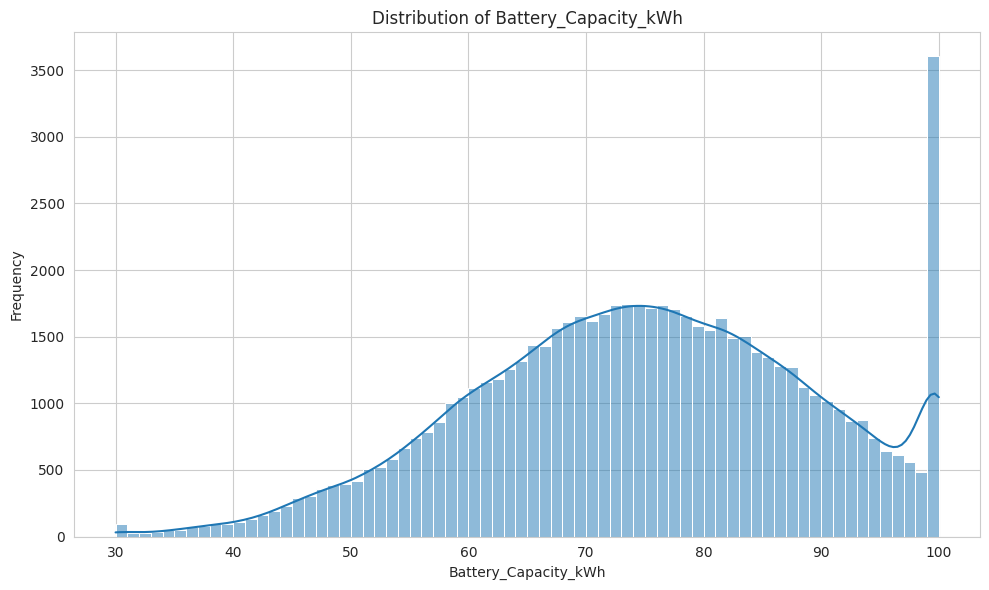

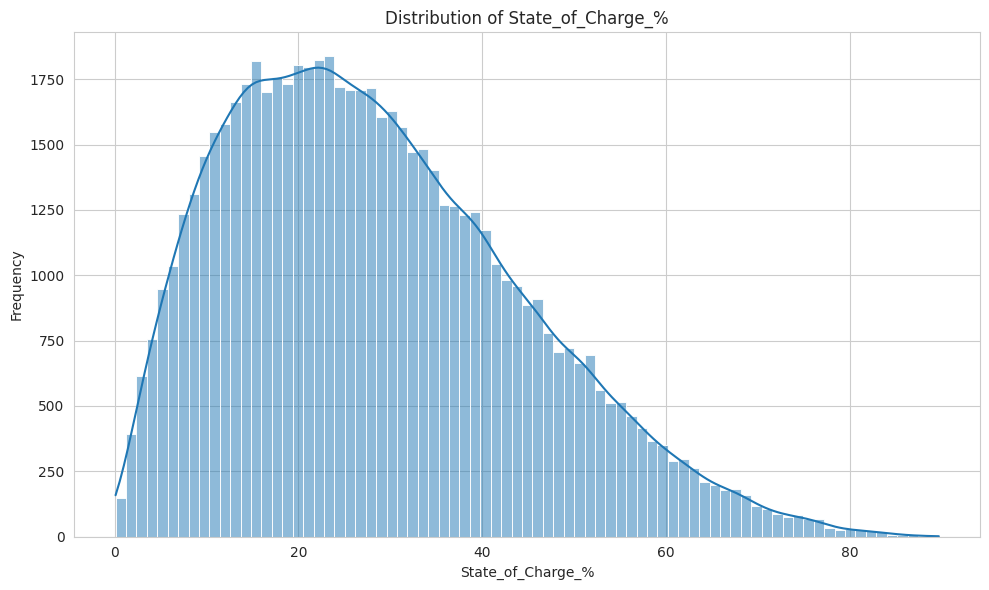

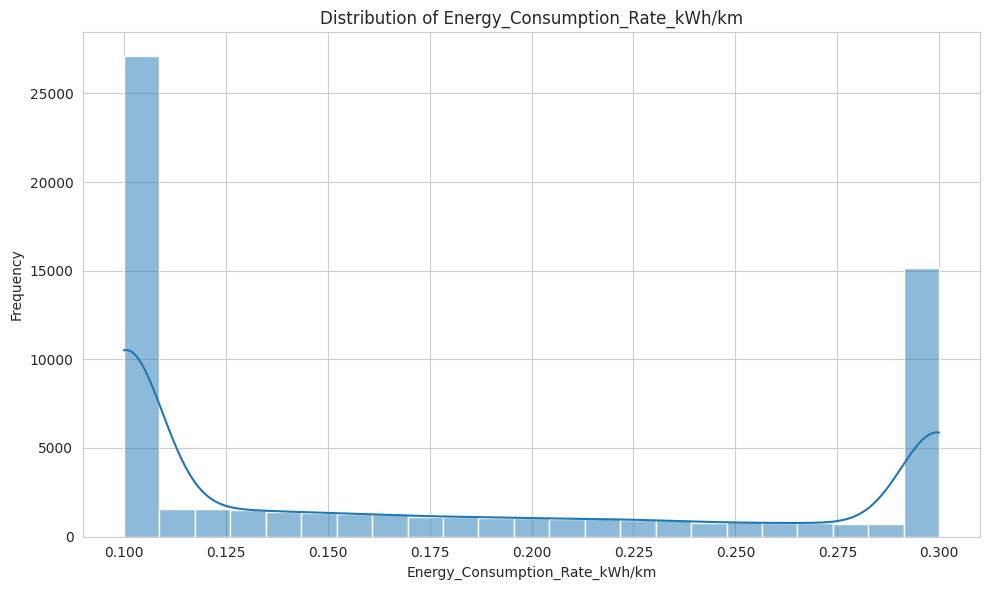

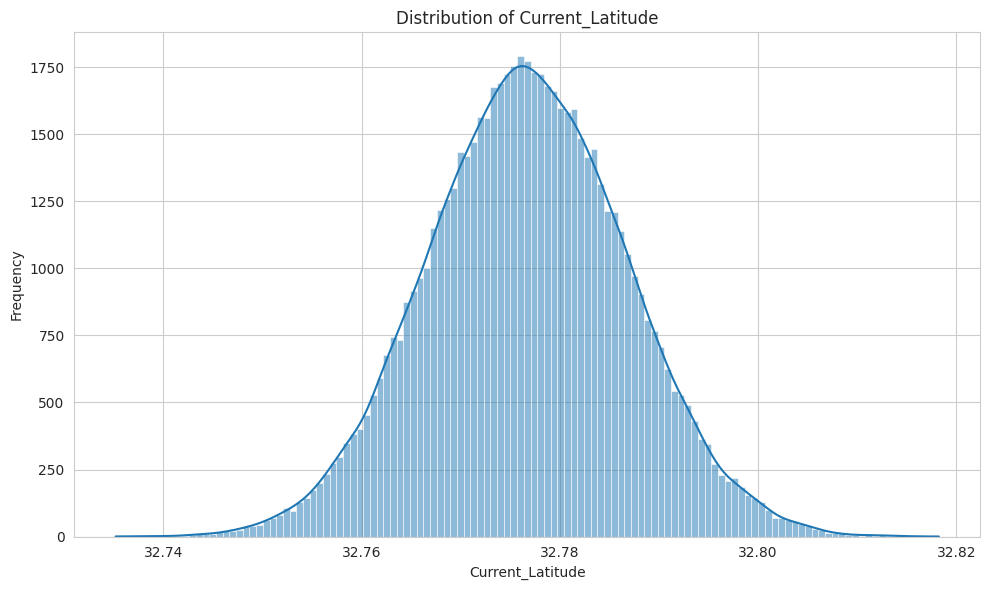

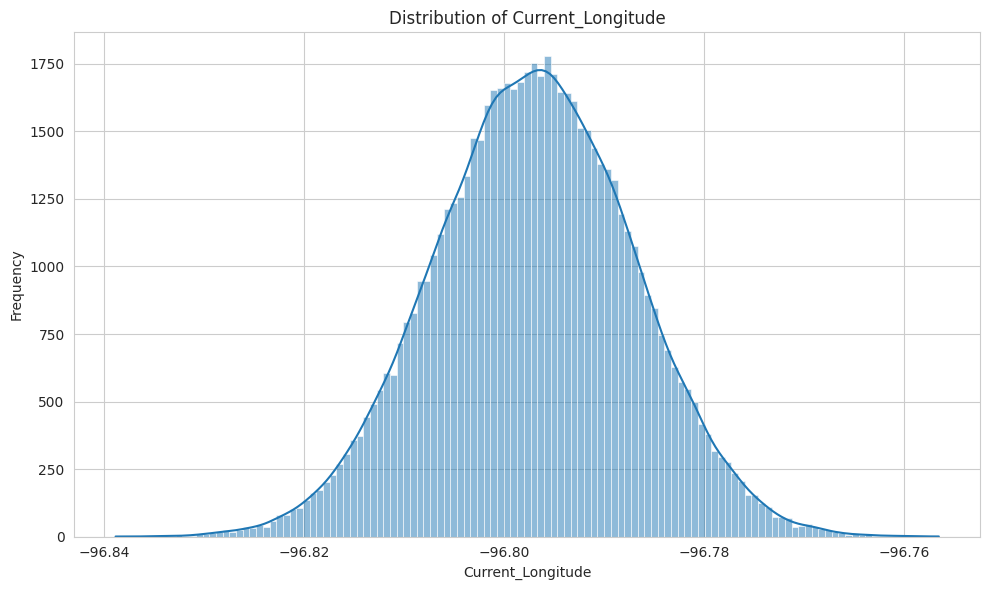

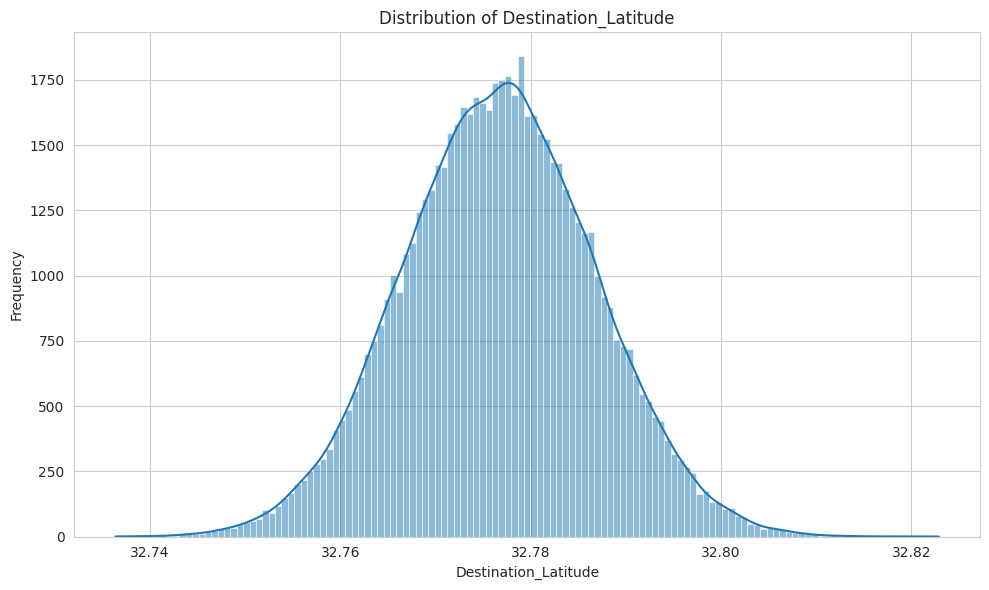

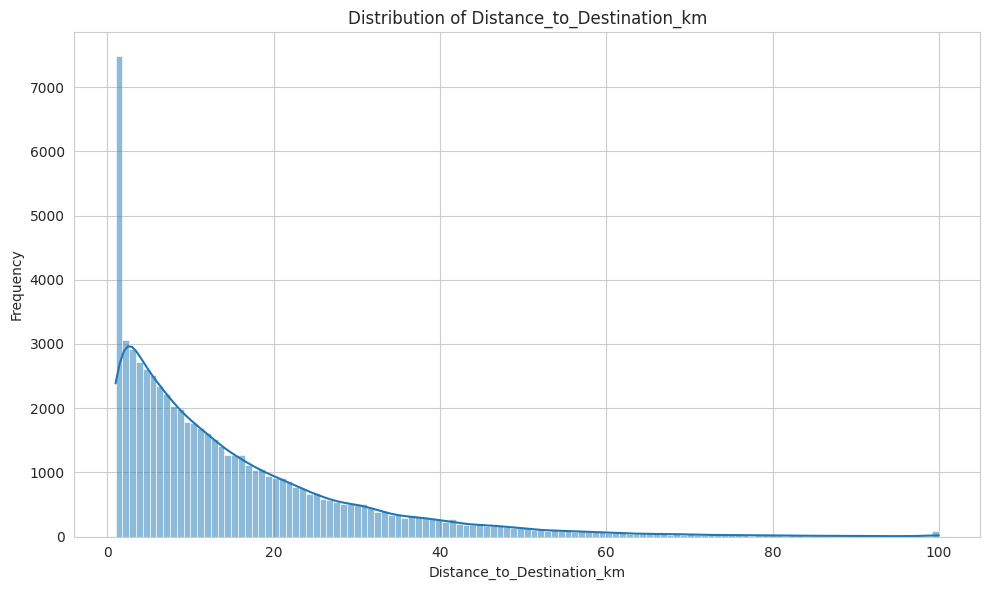

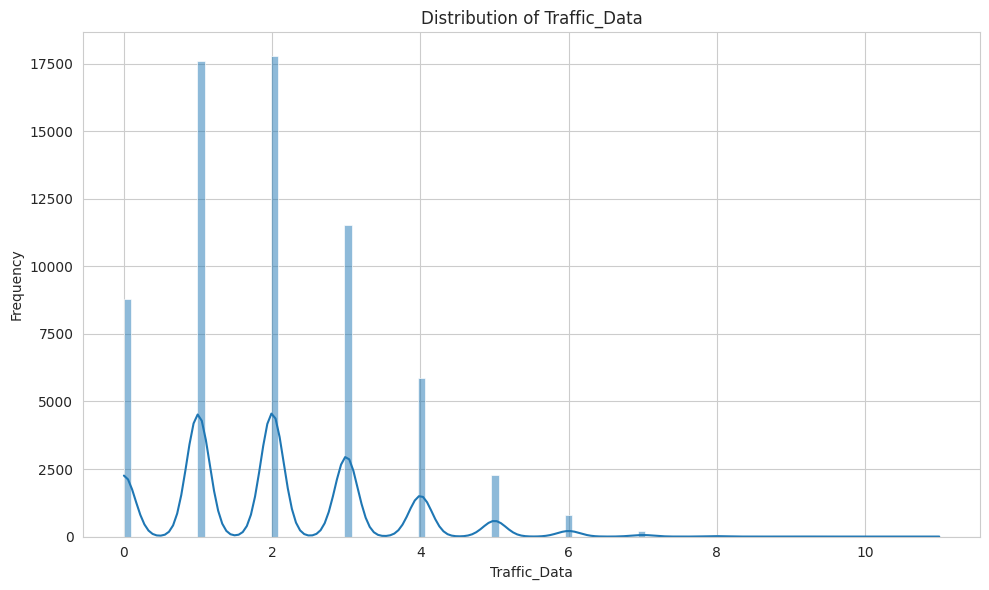

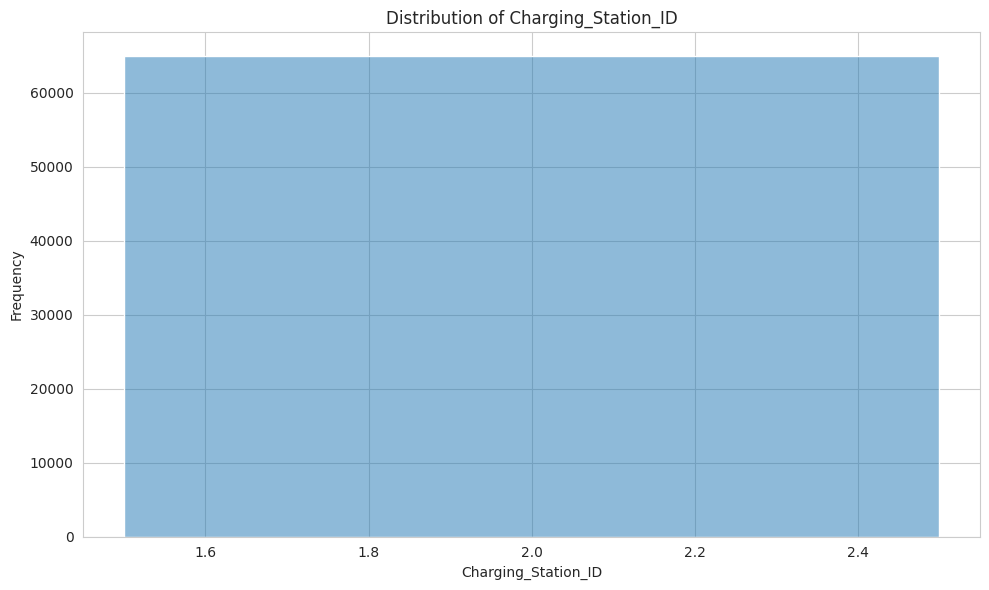

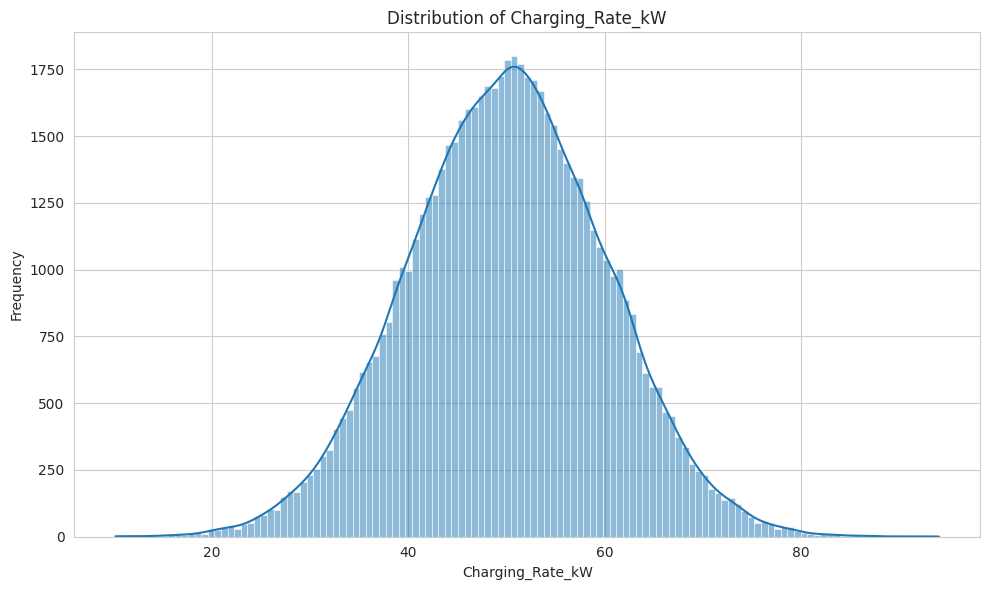

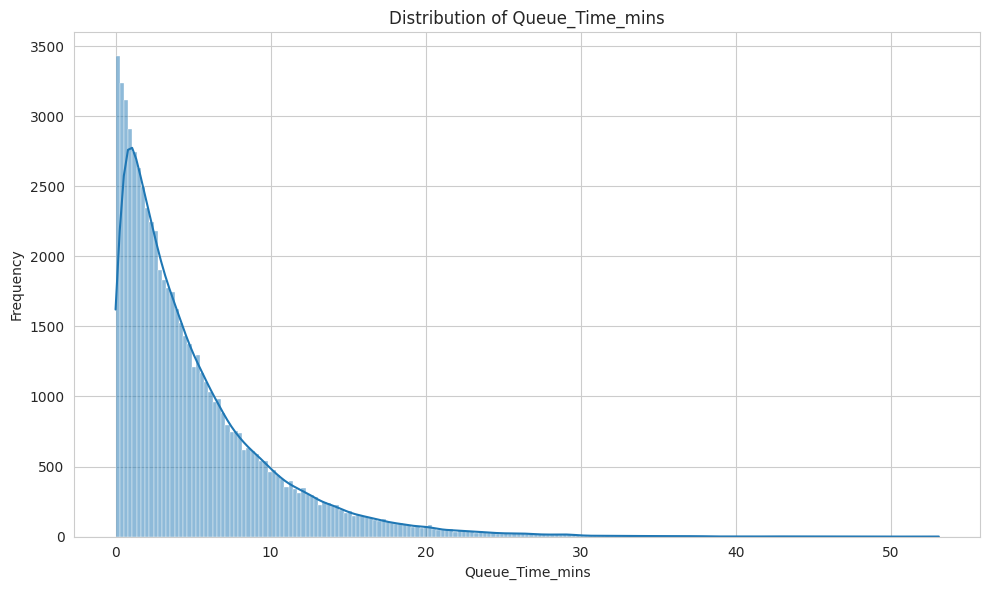

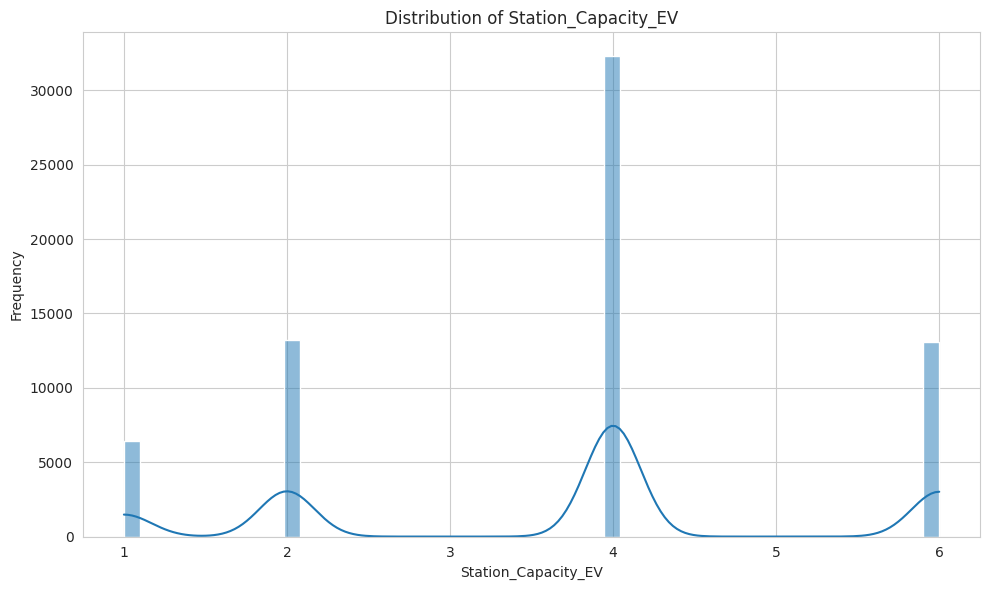

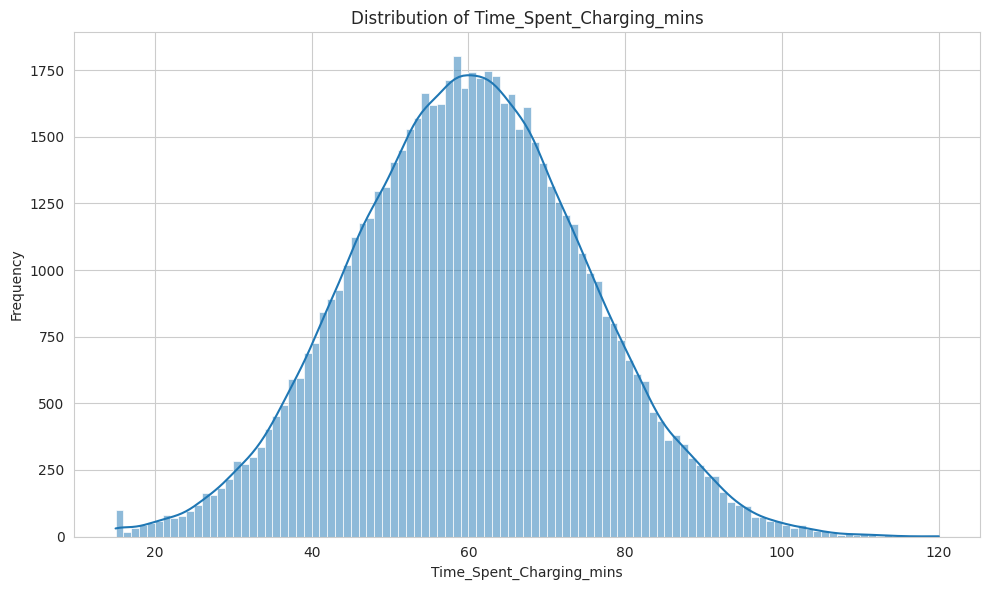

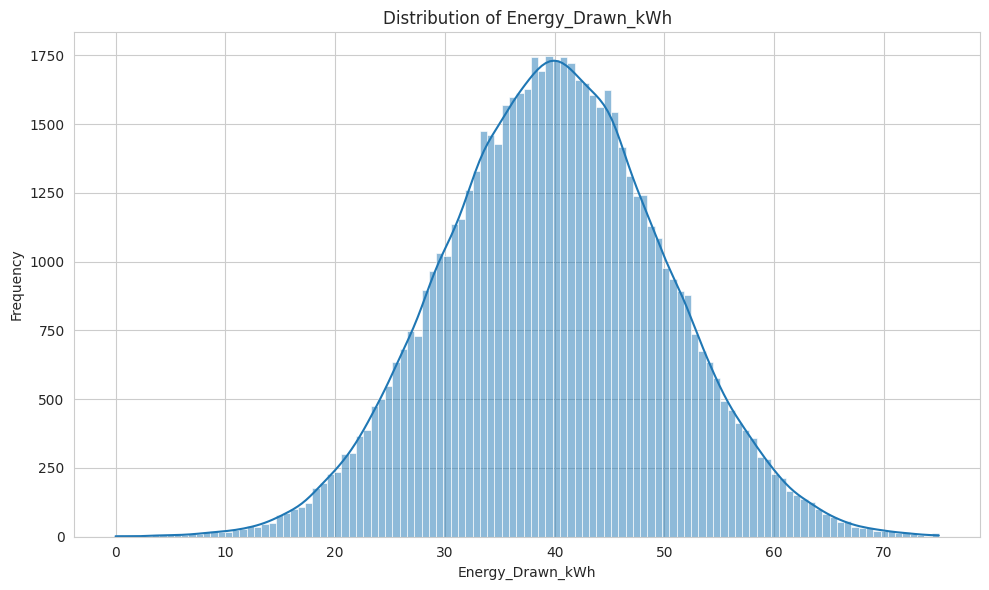

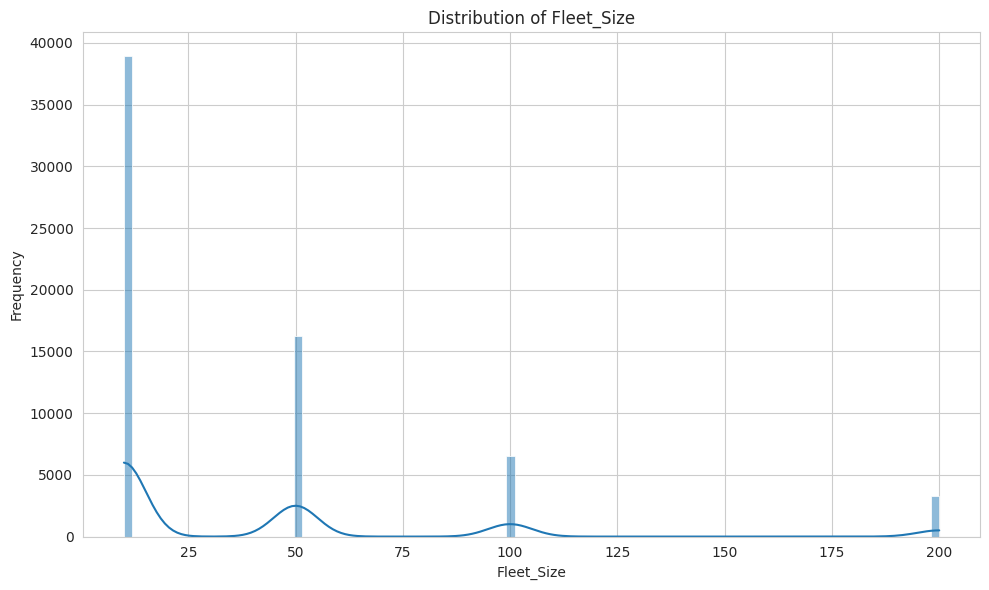

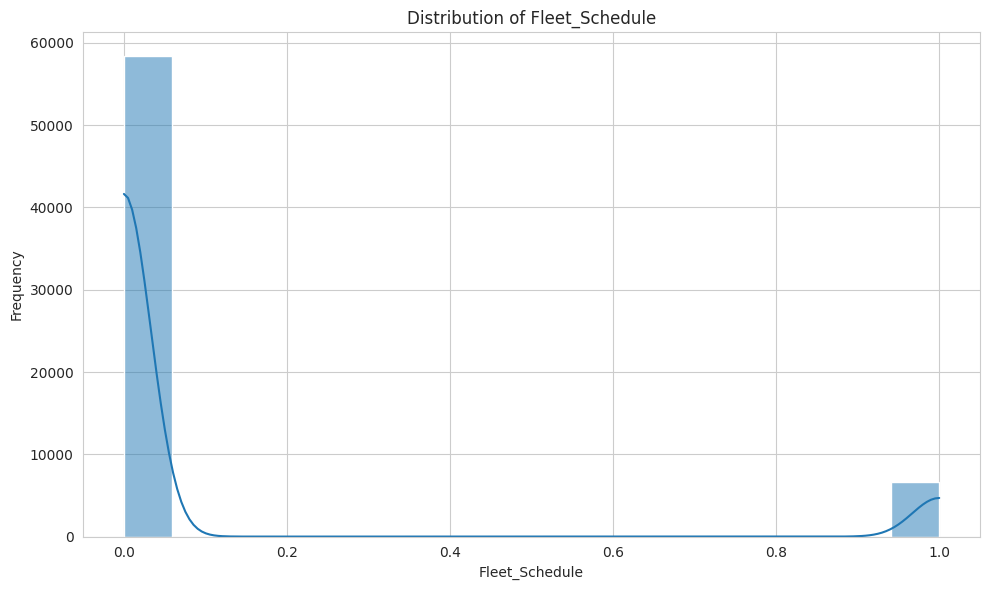

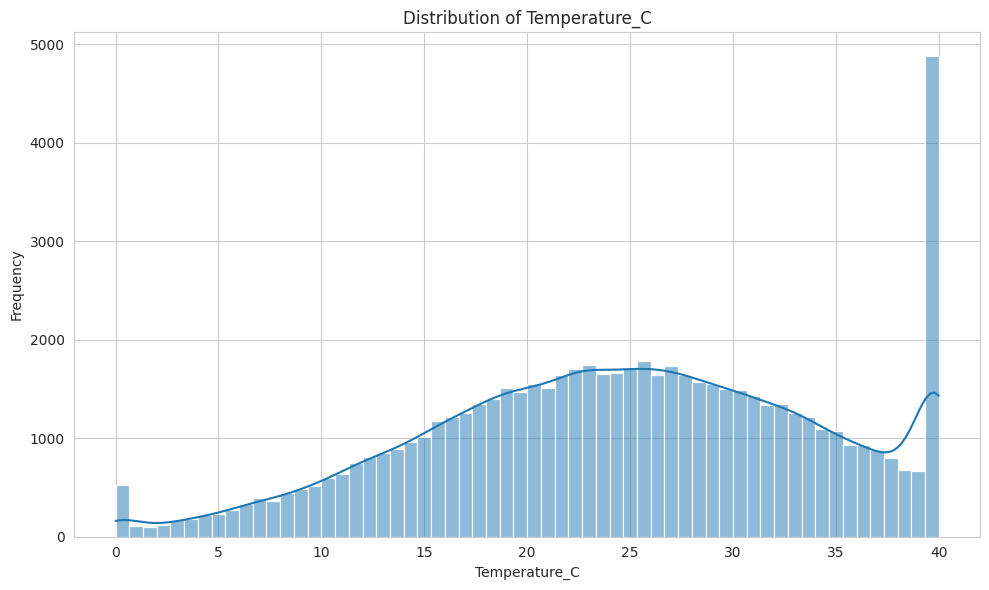

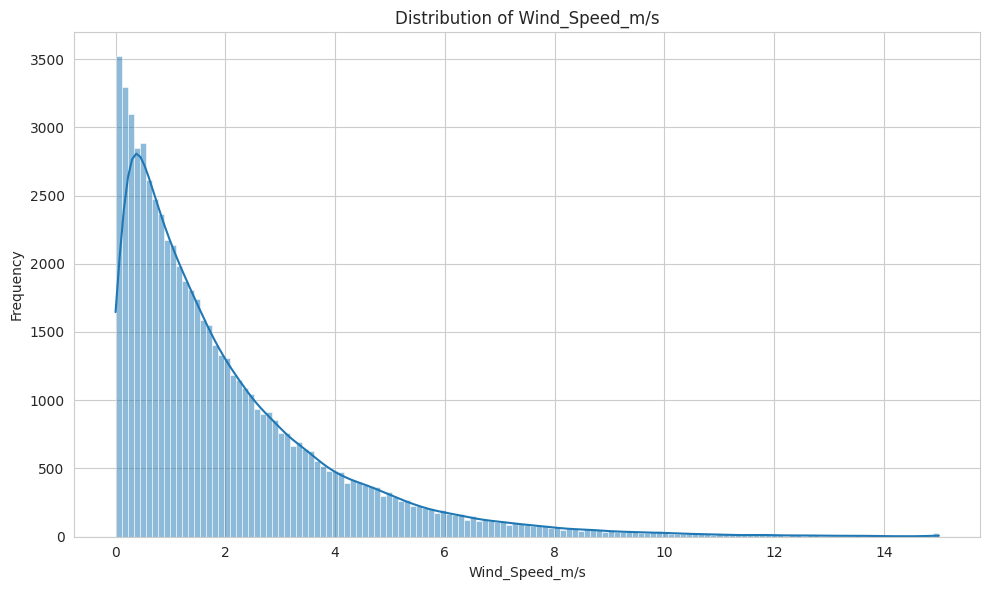

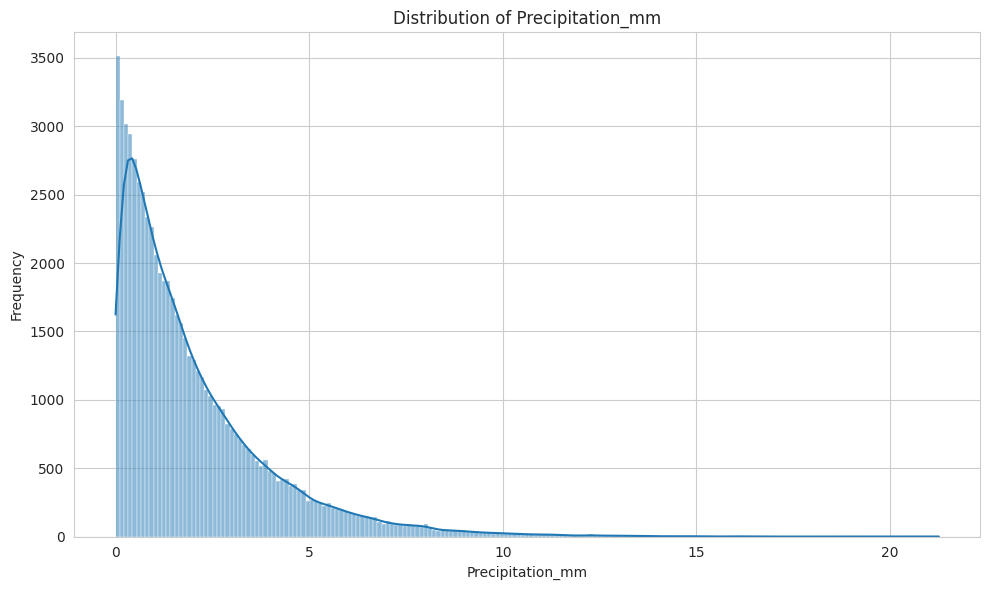

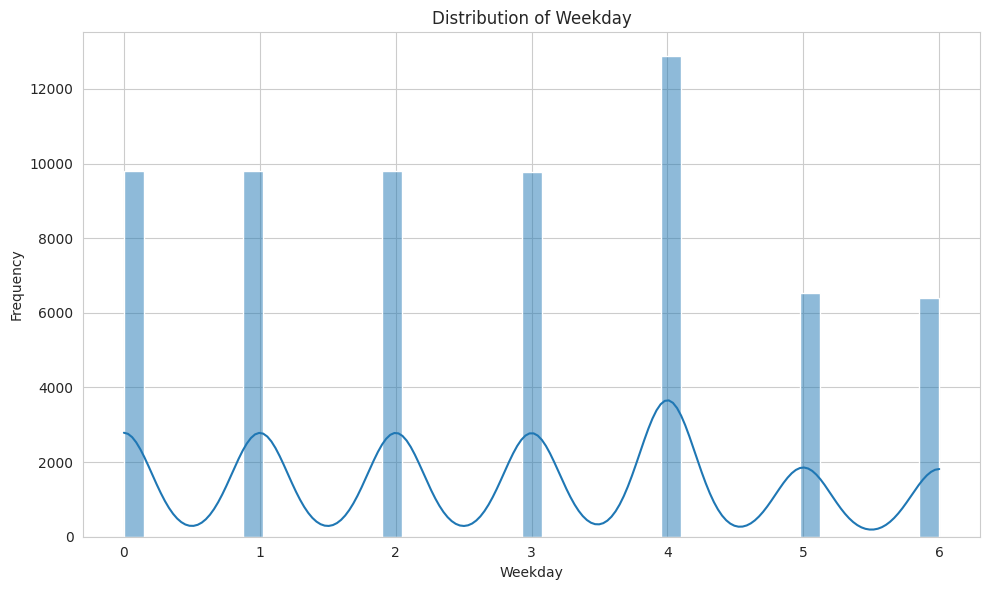

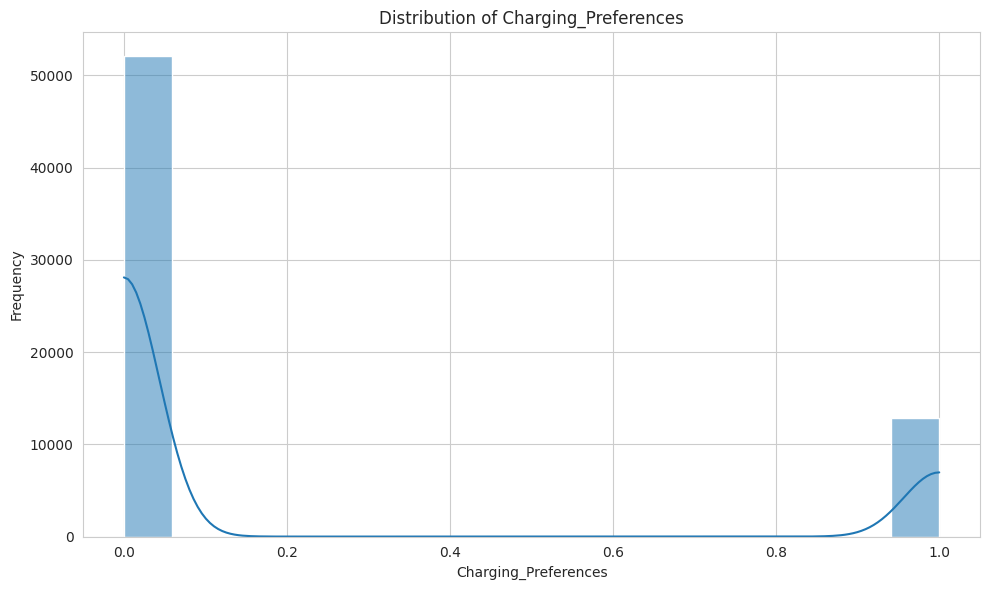

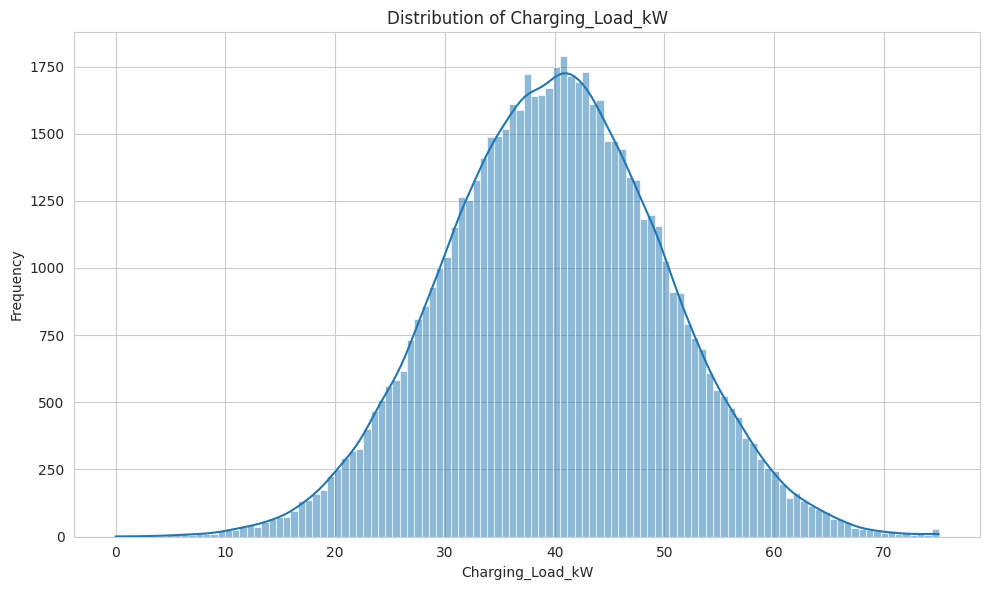


Generating bar plots for categorical columns...


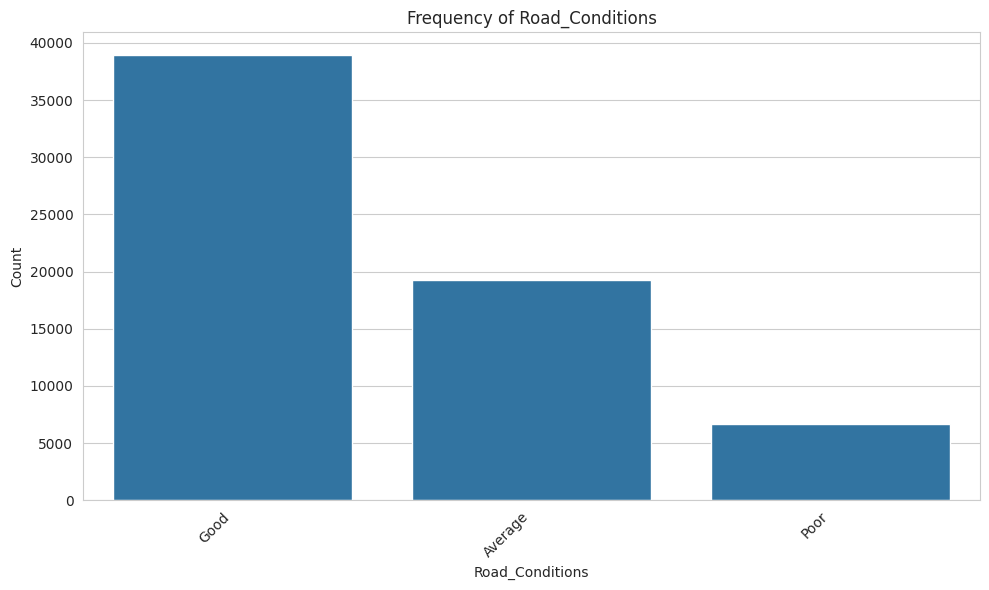

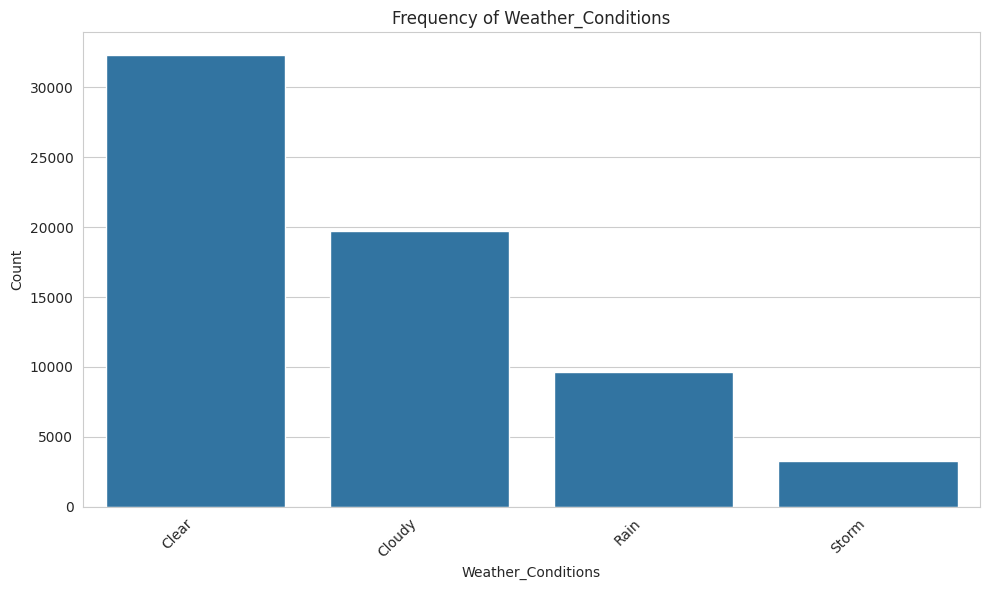

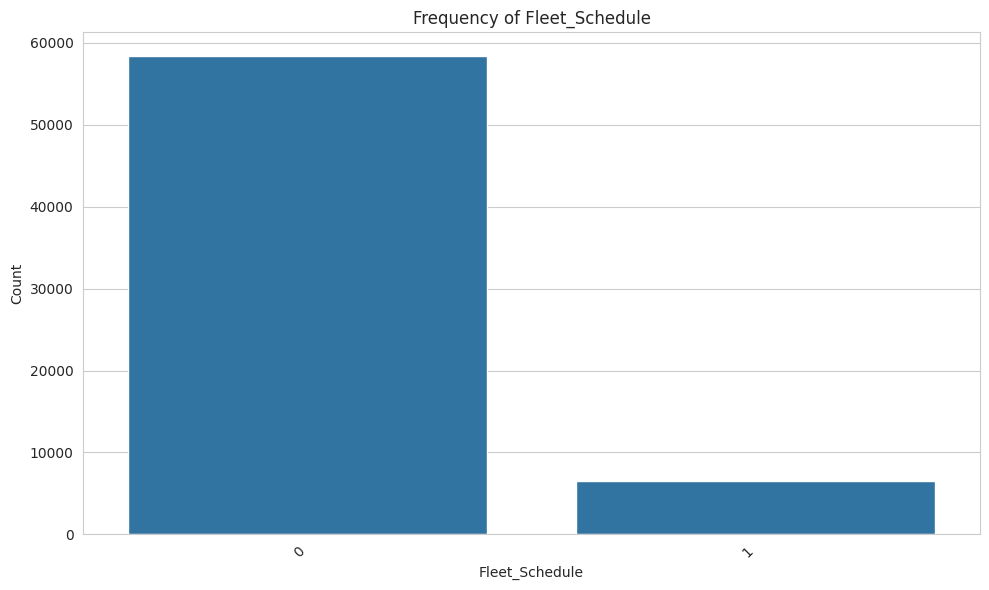

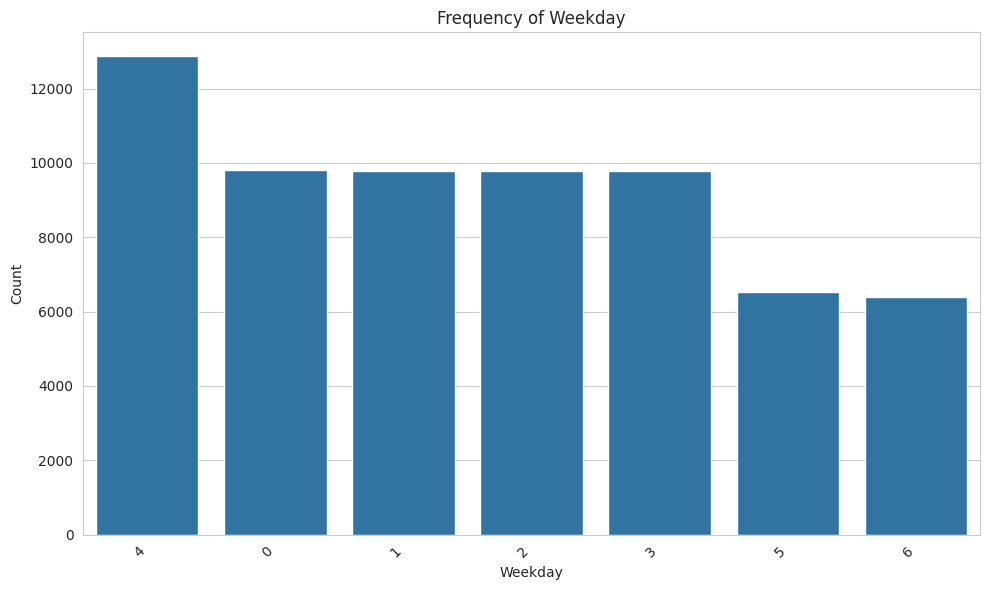

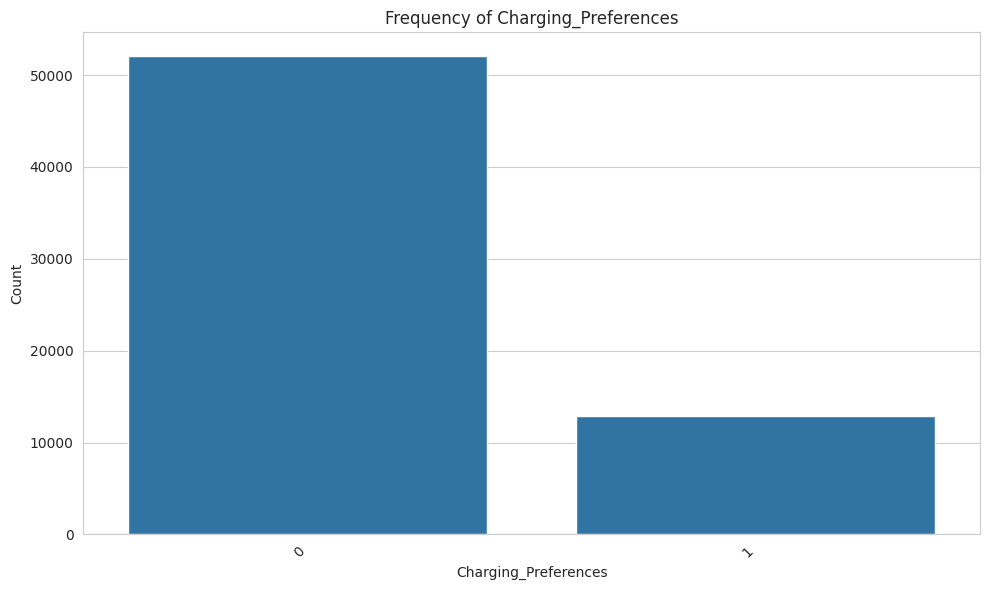

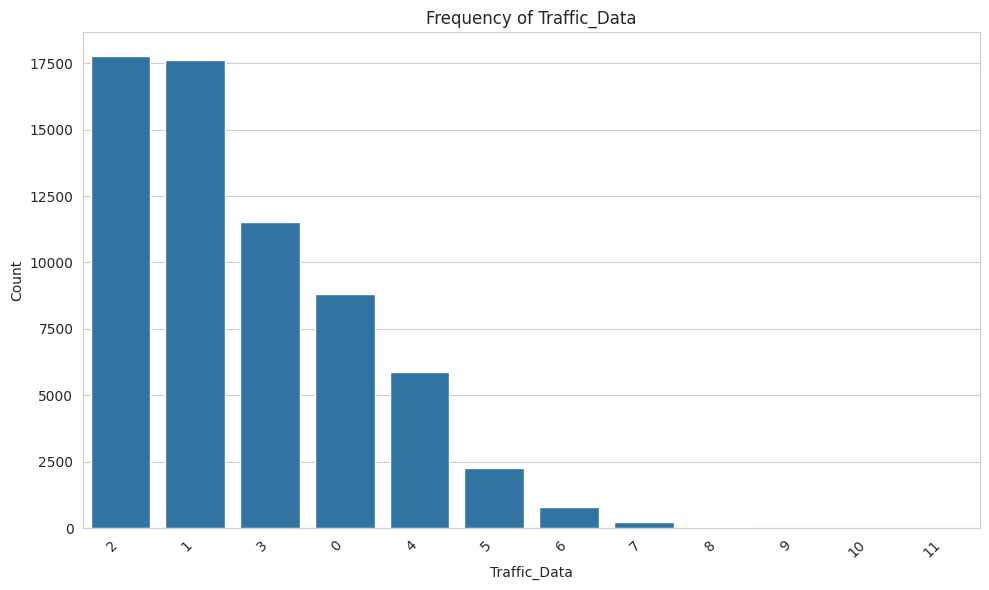

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for plots
sns.set_style("whitegrid")

# Plot histograms for numerical columns
print("Generating histograms for numerical columns...")
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(df_cleaned[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Plot bar plots for categorical columns
print("\nGenerating bar plots for categorical columns...")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_cleaned, x=col, order=df_cleaned[col].value_counts().index)
    plt.title(f'Frequency of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

Generating scatter plots for numerical variable pairs...


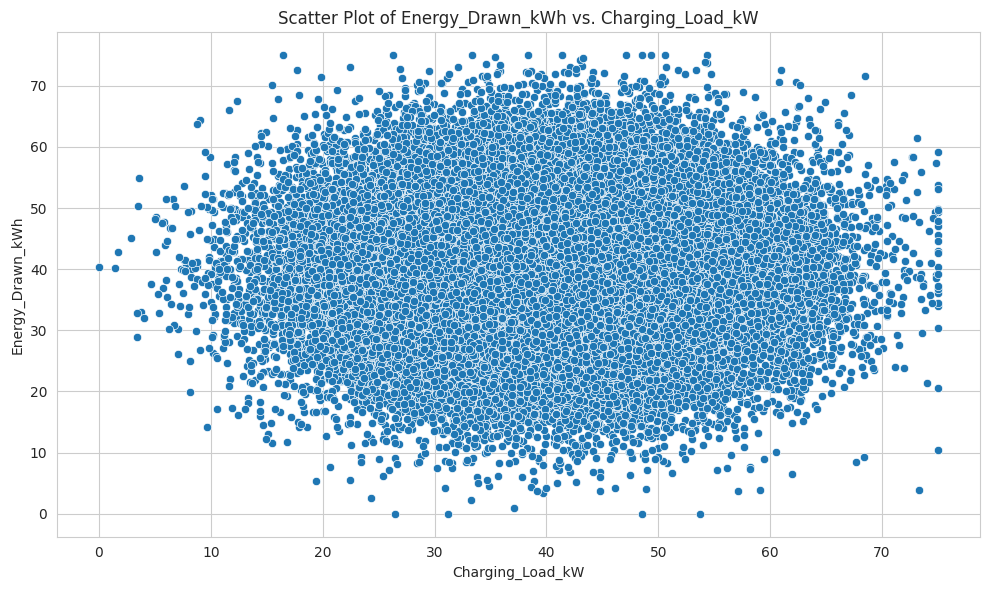

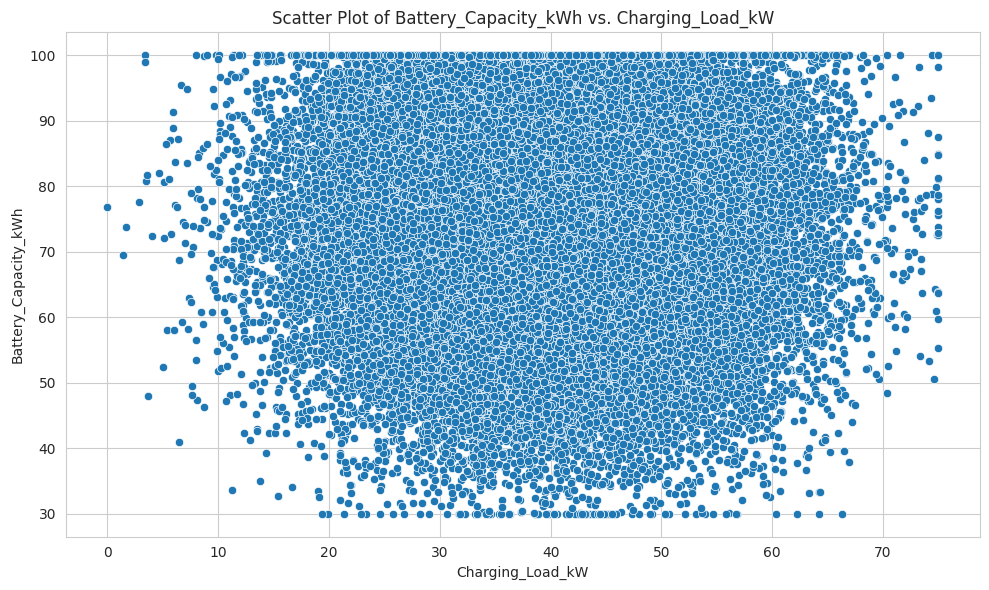

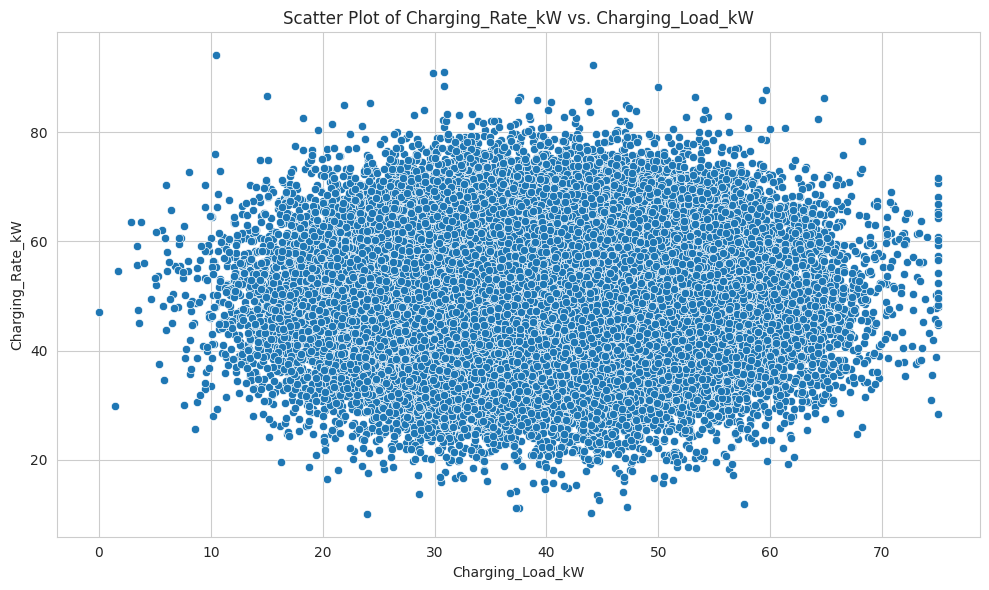

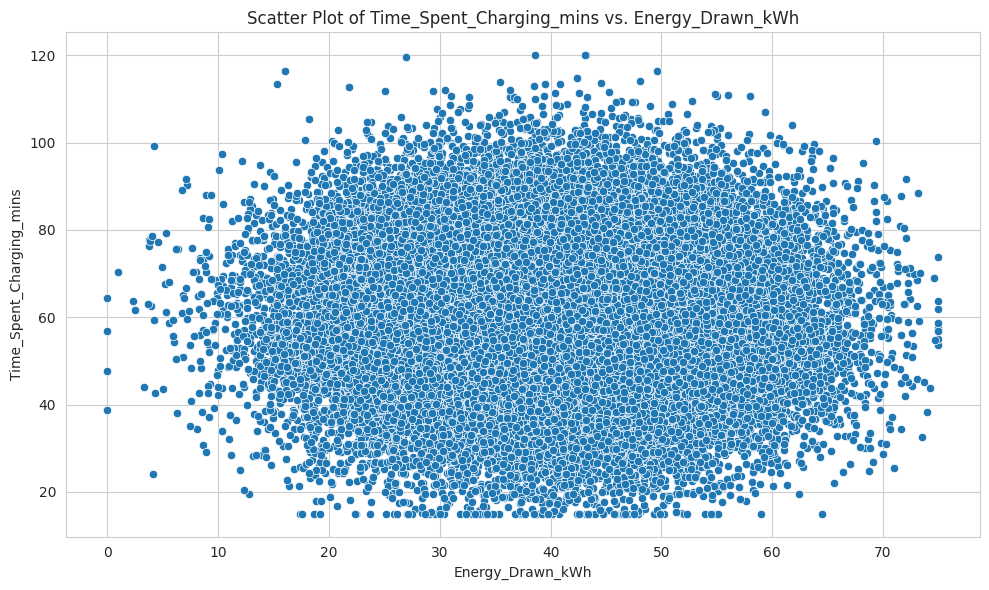

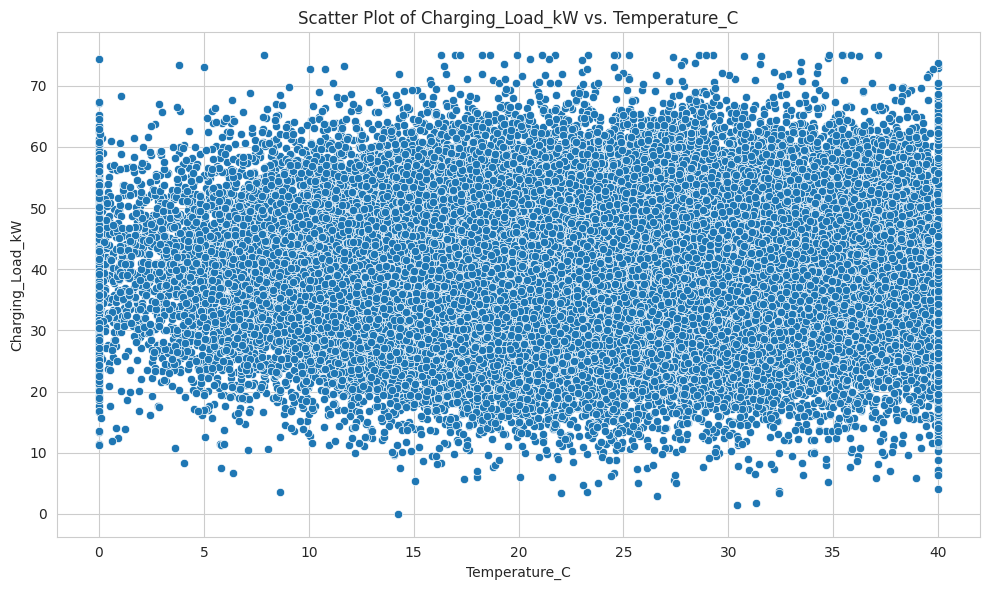

In [ ]:
print("Generating scatter plots for numerical variable pairs...")

# Define the pairs of numerical variables for scatter plots
scatter_plots_pairs = [
    ('Charging_Load_kW', 'Energy_Drawn_kWh'),
    ('Charging_Load_kW', 'Battery_Capacity_kWh'),
    ('Charging_Load_kW', 'Charging_Rate_kW'),
    ('Energy_Drawn_kWh', 'Time_Spent_Charging_mins'),
    ('Temperature_C', 'Charging_Load_kW')
]

for x_col, y_col in scatter_plots_pairs:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_cleaned, x=x_col, y=y_col)
    plt.title(f'Scatter Plot of {y_col} vs. {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

Generating box plots for numerical vs. categorical variables...


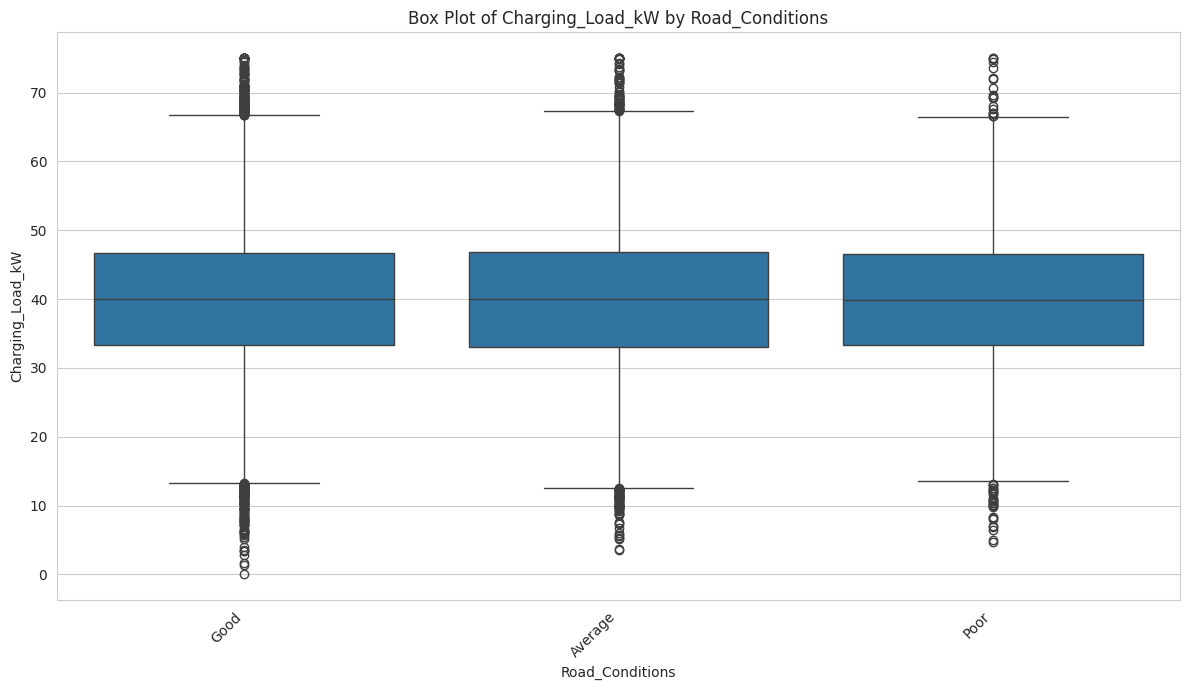

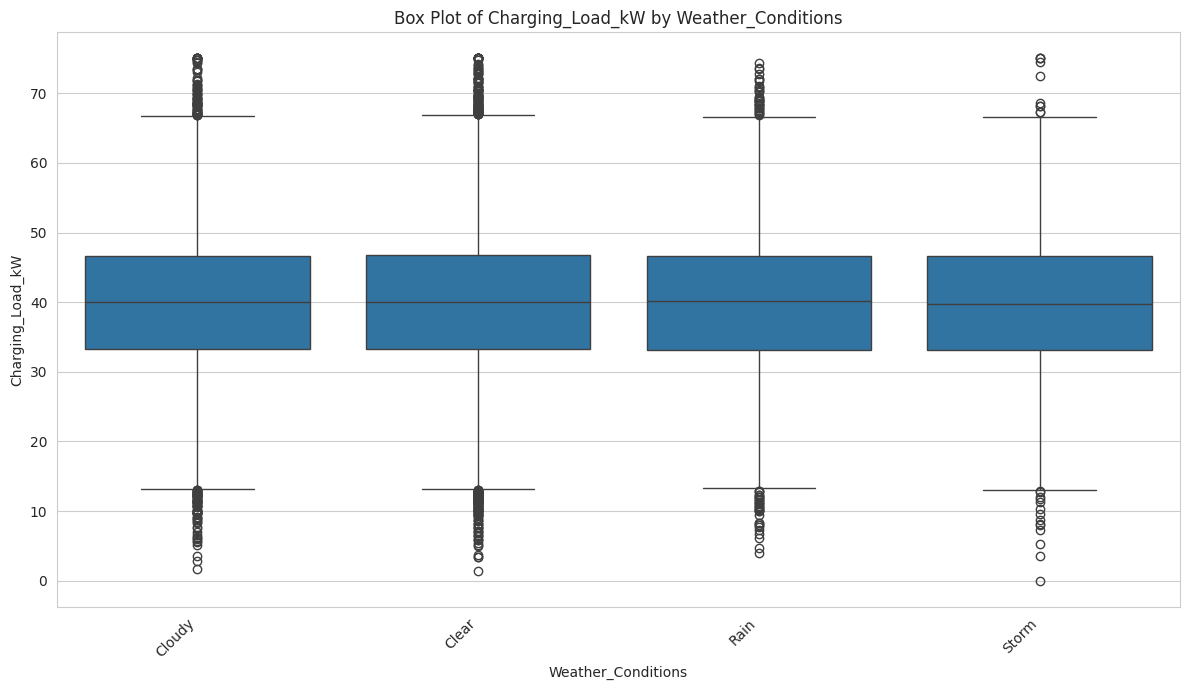

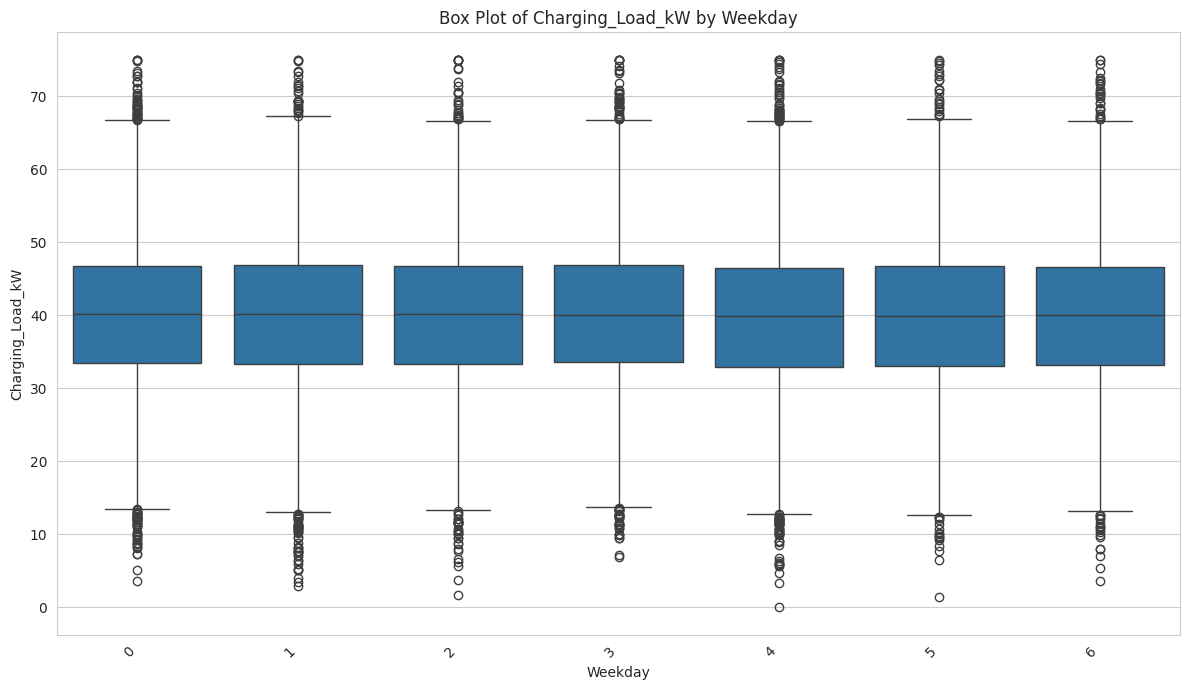

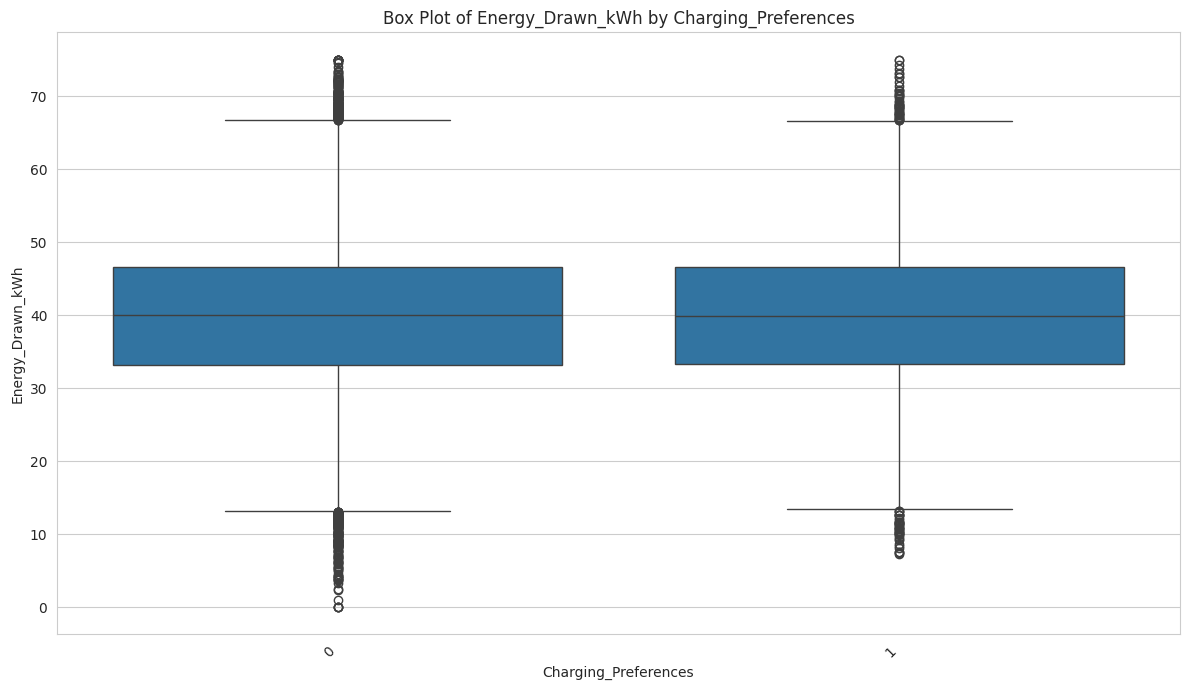

In [ ]:
print("Generating box plots for numerical vs. categorical variables...")

# Define the pairs of numerical and categorical variables for box plots
box_plots_pairs = [
    ('Charging_Load_kW', 'Road_Conditions'),
    ('Charging_Load_kW', 'Weather_Conditions'),
    ('Charging_Load_kW', 'Weekday'),
    ('Energy_Drawn_kWh', 'Charging_Preferences')
]

for y_col, x_col in box_plots_pairs:
    plt.figure(figsize=(12, 7))
    sns.boxplot(data=df_cleaned, x=x_col, y=y_col)
    plt.title(f'Box Plot of {y_col} by {x_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Calculating the Pearson correlation matrix for numerical columns...
Generating a heatmap visualization of the correlation matrix...


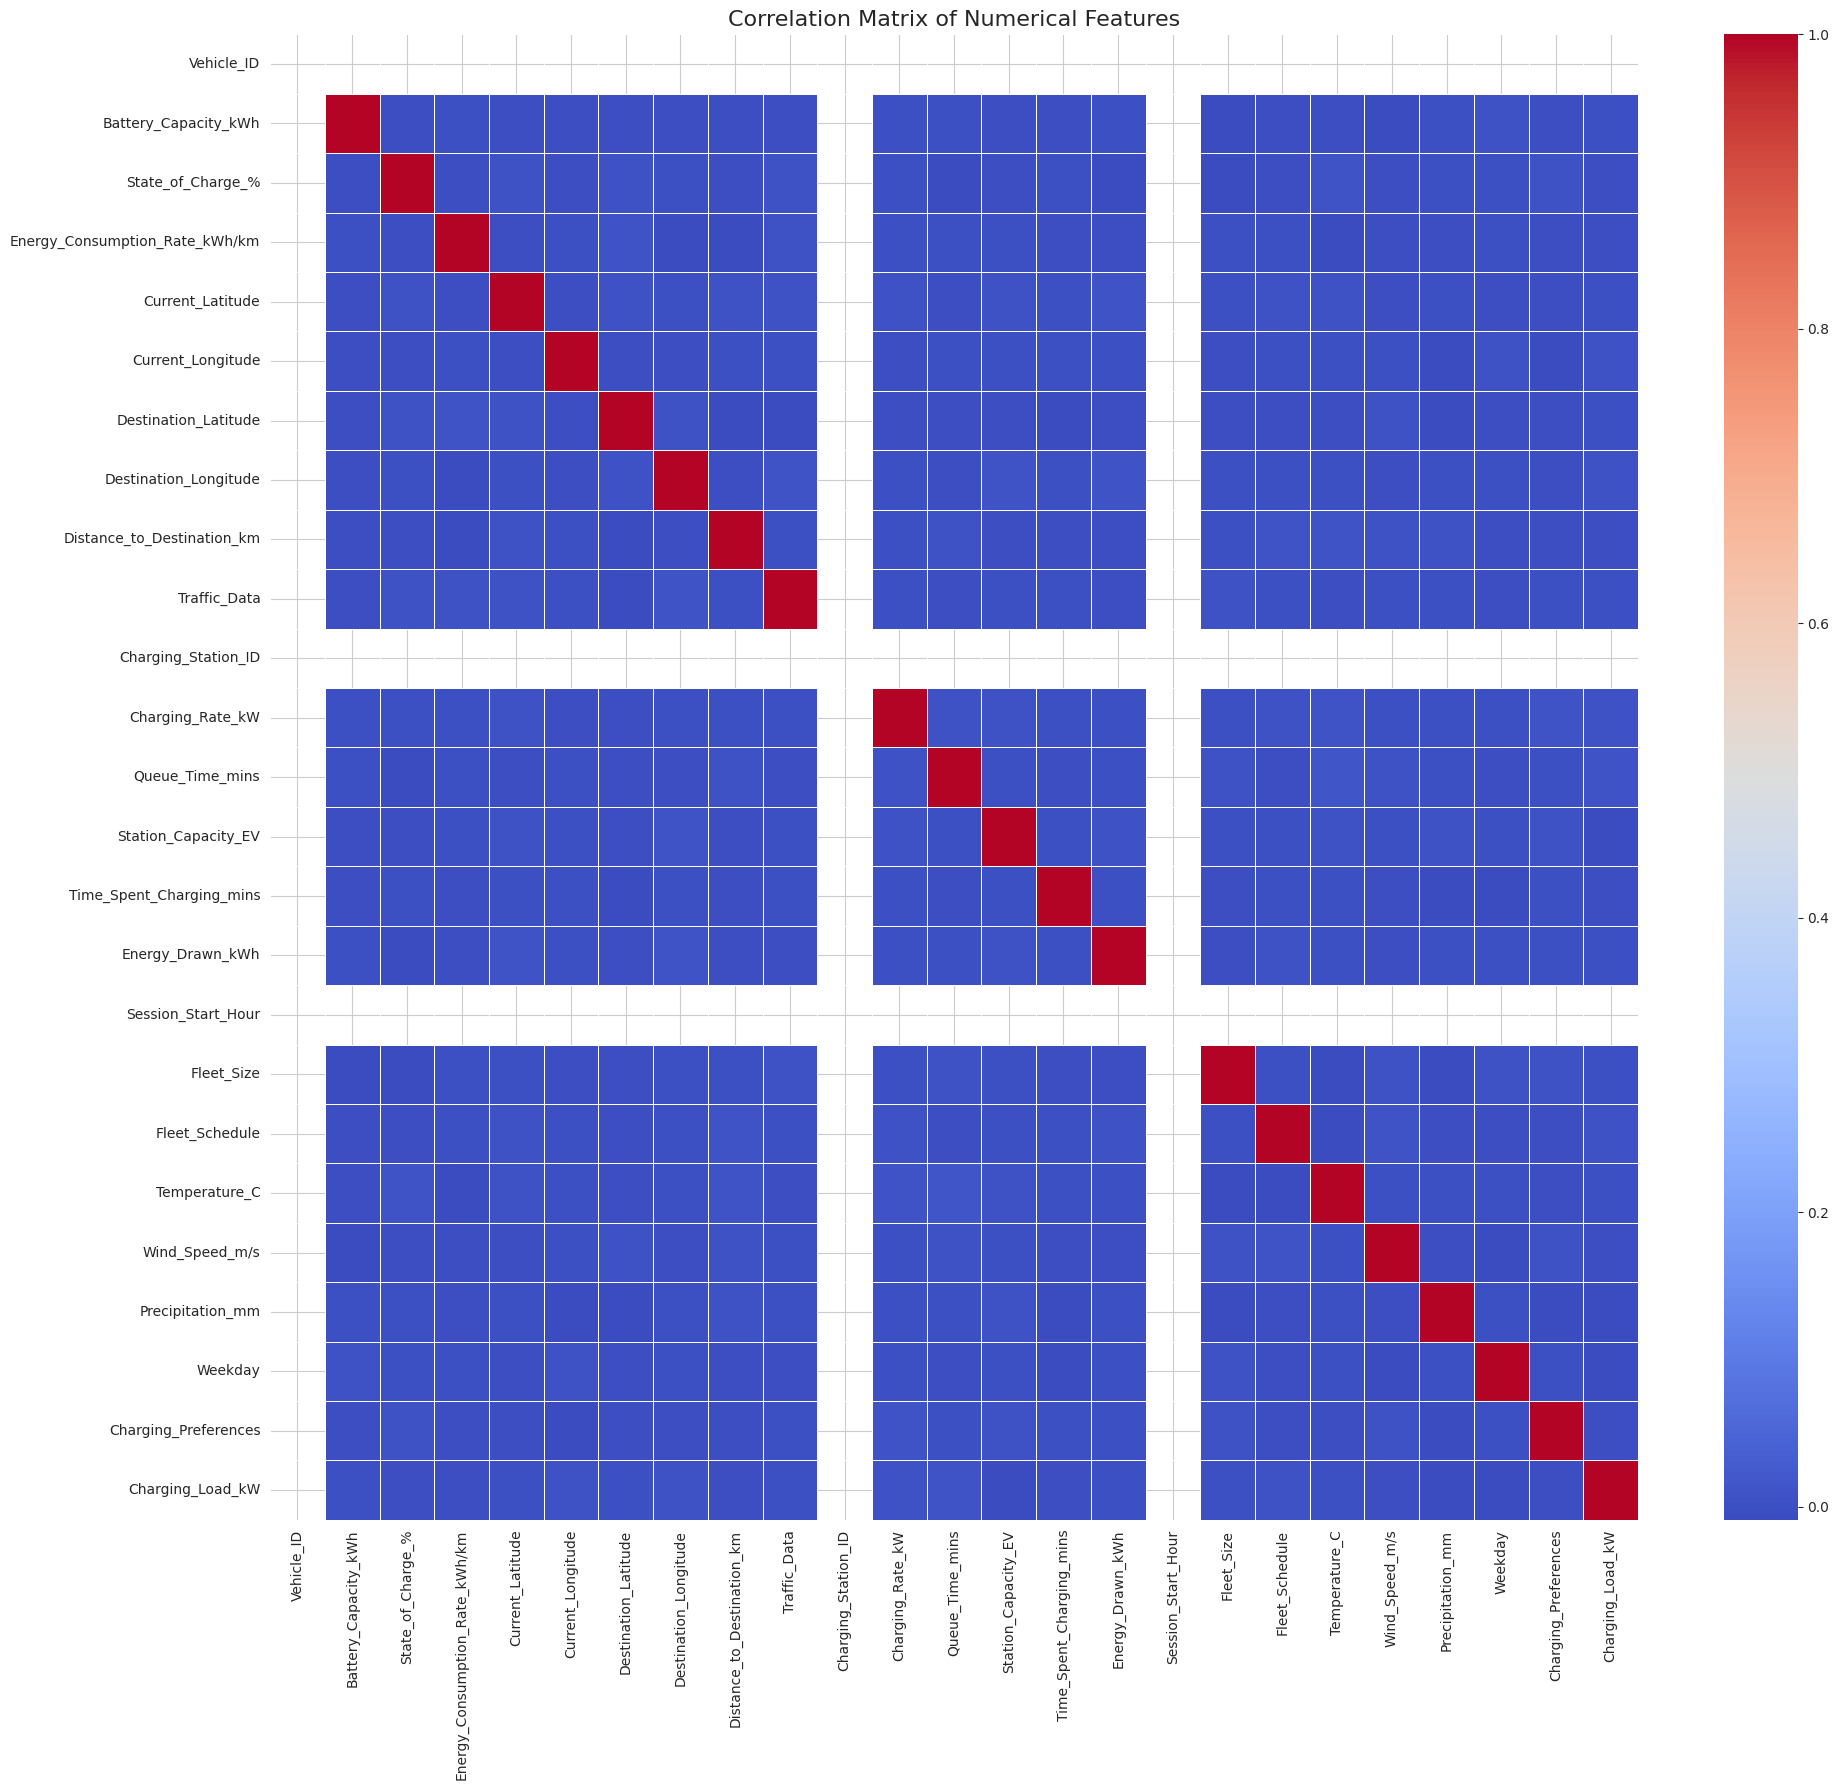

In [ ]:
print("Calculating the Pearson correlation matrix for numerical columns...")
# Calculate the correlation matrix for numerical columns
# Filter only numerical columns from df_cleaned
numerical_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr(method='pearson')

print("Generating a heatmap visualization of the correlation matrix...")
# Create a heatmap visualization of the correlation matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Generating time series plot for Charging Load Over Time...


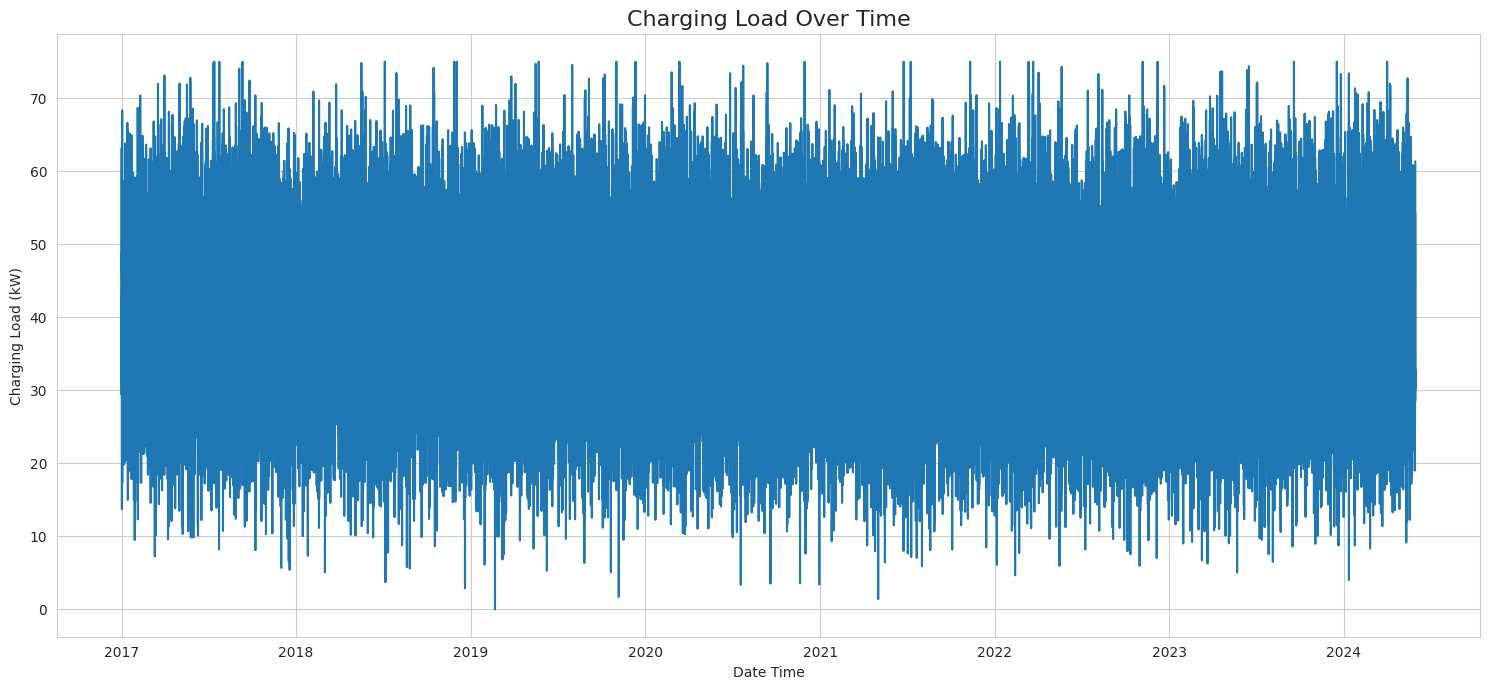

In [ ]:
print("Generating time series plot for Charging Load Over Time...")
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_cleaned, x='Date_Time', y='Charging_Load_kW')
plt.title('Charging Load Over Time', fontsize=16)
plt.xlabel('Date Time')
plt.ylabel('Charging Load (kW)')
plt.tight_layout()
plt.show()

Generating scatter plot with regression line for Charging Load vs. Temperature...


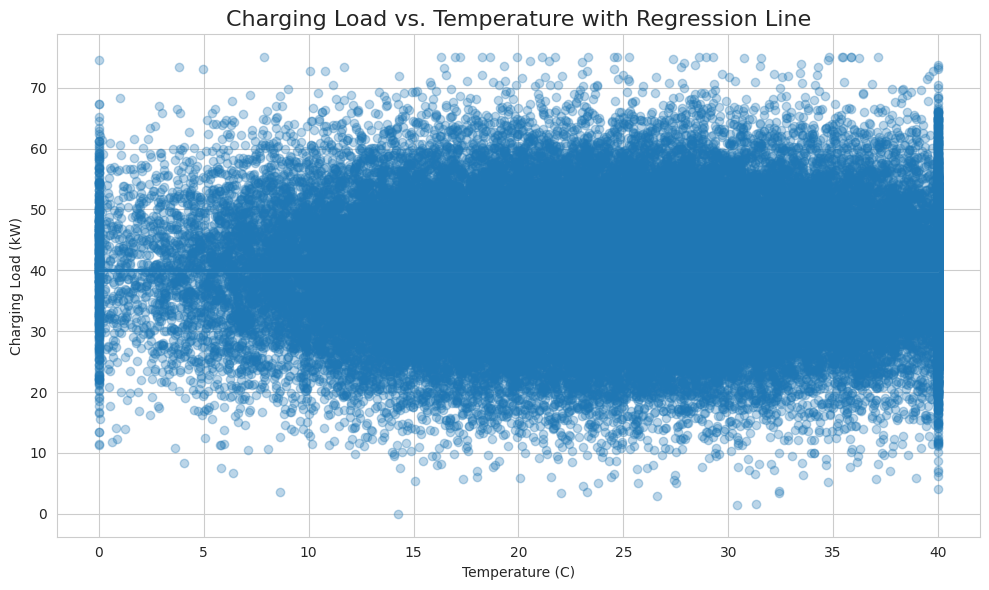

In [ ]:
print("Generating scatter plot with regression line for Charging Load vs. Temperature...")
plt.figure(figsize=(10, 6))
sns.regplot(data=df_cleaned, x='Temperature_C', y='Charging_Load_kW', scatter_kws={'alpha':0.3})
plt.title('Charging Load vs. Temperature with Regression Line', fontsize=16)
plt.xlabel('Temperature (C)')
plt.ylabel('Charging Load (kW)')
plt.tight_layout()
plt.show()

Generating box plot for Charging Load Distribution by Weather Condition...


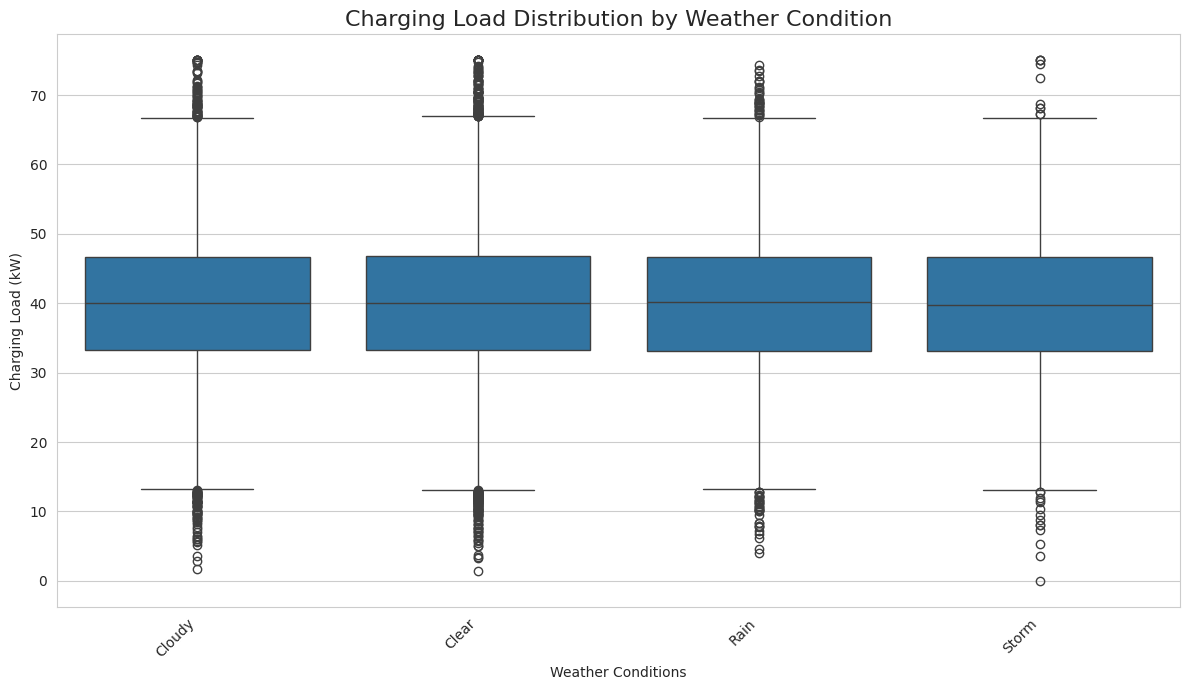

In [ ]:
print("Generating box plot for Charging Load Distribution by Weather Condition...")
plt.figure(figsize=(12, 7))
sns.boxplot(data=df_cleaned, x='Weather_Conditions', y='Charging_Load_kW')
plt.title('Charging Load Distribution by Weather Condition', fontsize=16)
plt.xlabel('Weather Conditions')
plt.ylabel('Charging Load (kW)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Select all numerical columns from the df_cleaned DataFrame
numerical_cols_pca = df_cleaned.select_dtypes(include=['float64', 'int64']).columns.tolist()

# 2. Exclude the columns 'Vehicle_ID', 'Session_Start_Hour', and 'Destination_Longitude'
exclude_cols_pca = ['Vehicle_ID', 'Session_Start_Hour', 'Destination_Longitude']
numerical_cols_pca = [col for col in numerical_cols_pca if col not in exclude_cols_pca]

# Create a DataFrame with only the selected numerical features
df_pca = df_cleaned[numerical_cols_pca]

# 3. Instantiate a StandardScaler object
scaler = StandardScaler()

# 4. Fit the scaler to the selected numerical features and transform them
scaled_features = scaler.fit_transform(df_pca)

# Convert the scaled features back to a DataFrame for easier handling
scaled_features_df = pd.DataFrame(scaled_features, columns=numerical_cols_pca, index=df_pca.index)

print("Selected numerical columns for PCA:", numerical_cols_pca)
print("Shape of original PCA DataFrame:", df_pca.shape)
print("Shape of scaled features DataFrame:", scaled_features_df.shape)
print("First 5 rows of scaled features:")
print(scaled_features_df.head())

Selected numerical columns for PCA: ['Battery_Capacity_kWh', 'State_of_Charge_%', 'Energy_Consumption_Rate_kWh/km', 'Current_Latitude', 'Current_Longitude', 'Destination_Latitude', 'Distance_to_Destination_km', 'Traffic_Data', 'Charging_Station_ID', 'Charging_Rate_kW', 'Queue_Time_mins', 'Station_Capacity_EV', 'Time_Spent_Charging_mins', 'Energy_Drawn_kWh', 'Fleet_Size', 'Fleet_Schedule', 'Temperature_C', 'Wind_Speed_m/s', 'Precipitation_mm', 'Weekday', 'Charging_Preferences', 'Charging_Load_kW']
Shape of original PCA DataFrame: (64945, 22)
Shape of scaled features DataFrame: (64945, 22)
First 5 rows of scaled features:
   Battery_Capacity_kWh  State_of_Charge_%  Energy_Consumption_Rate_kWh/km  \
0             -0.556189           1.363616                       -0.283543   
1              0.558037           1.937160                       -0.696177   
2              0.514570          -0.879579                       -0.925171   
3              1.449922          -0.343613                  

In [ ]:
from sklearn.decomposition import PCA

# Instantiate PCA without specifying the number of components
pca = PCA()

# Fit PCA to the scaled numerical data
pca.fit(scaled_features_df)

# Calculate the explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

print("Explained variance ratio for each principal component:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {ratio:.4f}")

Explained variance ratio for each principal component:
Principal Component 1: 0.0492
Principal Component 2: 0.0489
Principal Component 3: 0.0487
Principal Component 4: 0.0485
Principal Component 5: 0.0484
Principal Component 6: 0.0483
Principal Component 7: 0.0482
Principal Component 8: 0.0481
Principal Component 9: 0.0479
Principal Component 10: 0.0477
Principal Component 11: 0.0477
Principal Component 12: 0.0474
Principal Component 13: 0.0473
Principal Component 14: 0.0471
Principal Component 15: 0.0470
Principal Component 16: 0.0469
Principal Component 17: 0.0469
Principal Component 18: 0.0467
Principal Component 19: 0.0465
Principal Component 20: 0.0464
Principal Component 21: 0.0463
Principal Component 22: 0.0000


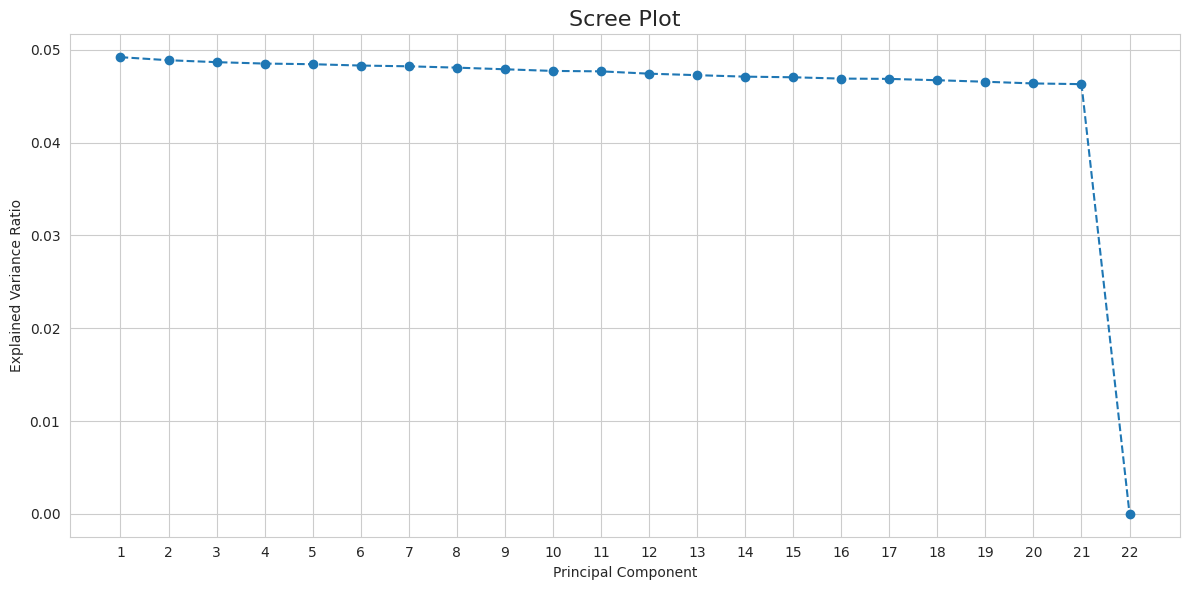

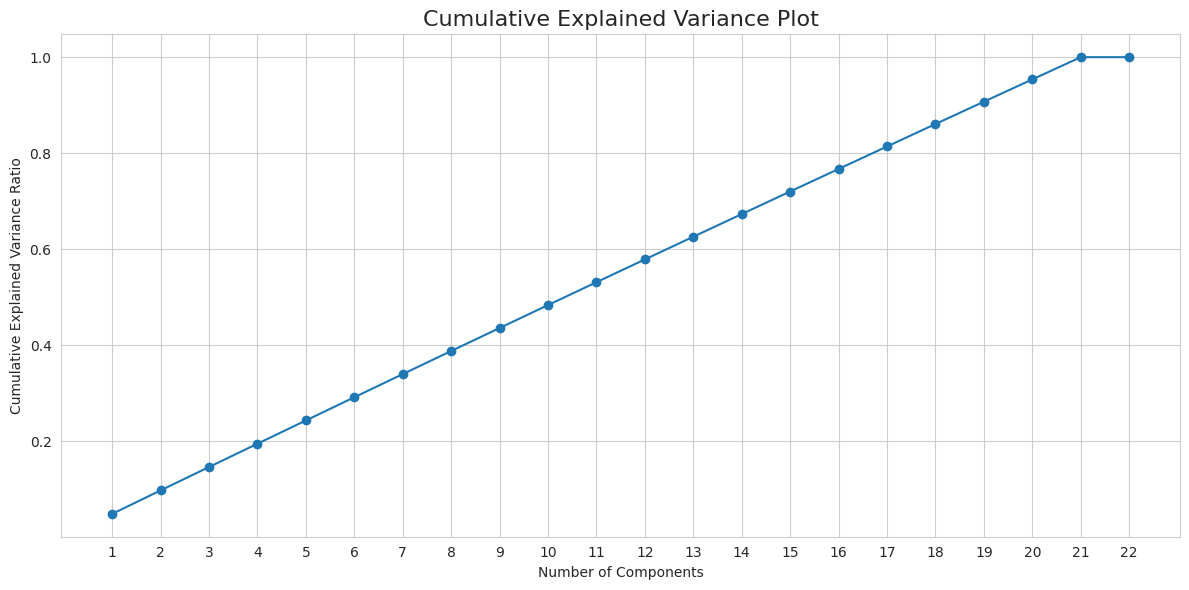

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Calculate cumulative explained variance
cum_explained_variance = np.cumsum(explained_variance_ratio)

# 1. Create a scree plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
plt.title('Scree Plot', fontsize=16)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.tight_layout()
plt.show()

# 2. Create a cumulative explained variance plot
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cum_explained_variance) + 1), cum_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance Plot', fontsize=16)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xticks(range(1, len(cum_explained_variance) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

Transforming data using PCA and generating a scatter plot of the first two principal components...


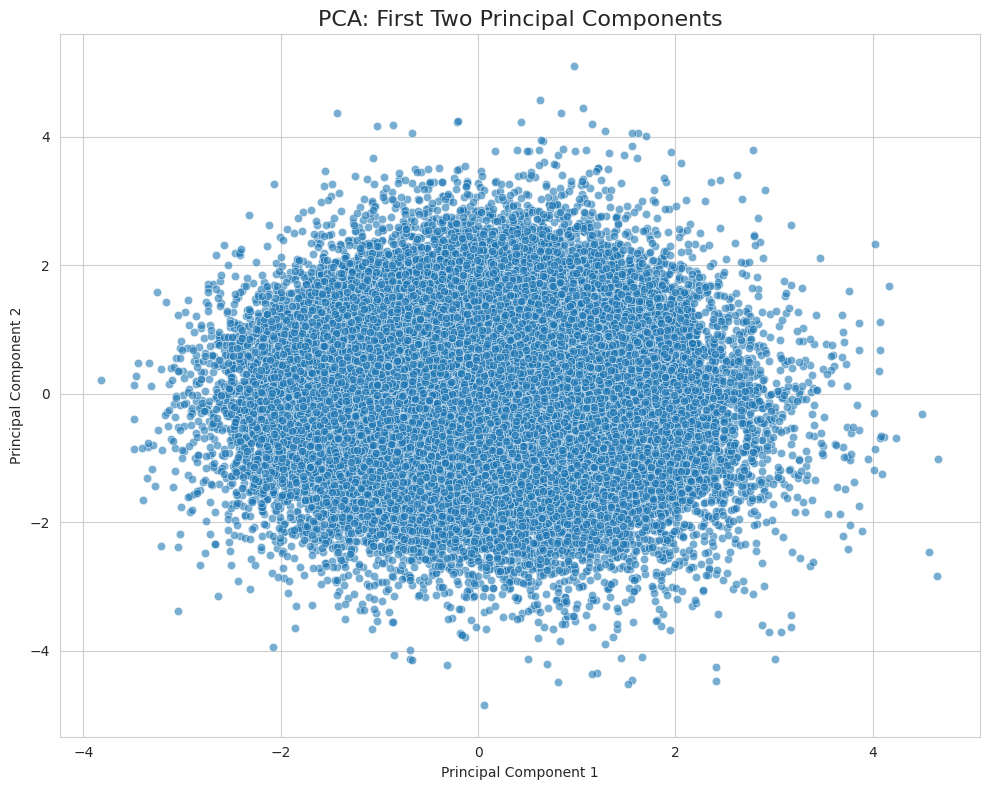

In [ ]:
print("Transforming data using PCA and generating a scatter plot of the first two principal components...")

# Transform the scaled_features_df using the fitted PCA model
principal_components = pca.transform(scaled_features_df)

# Create a DataFrame from the transformed components
pc_df = pd.DataFrame(data = principal_components,
                     columns = [f'Principal Component {i+1}' for i in range(principal_components.shape[1])],
                     index=scaled_features_df.index)

# Create a scatter plot of the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=pc_df, alpha=0.6)
plt.title('PCA: First Two Principal Components', fontsize=16)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import random

# Set a global seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# 1. Define the target variable 'y'
y = df_cleaned['Charging_Load_kW']

# 2. Define the features 'X' using the first 17 principal components
X = pc_df.iloc[:, :17]

# 3. Split the data using the fixed seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Data split using random_state={RANDOM_SEED}")
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Data split using random_state=42
Shape of X_train: (51956, 17)
Shape of X_test: (12989, 17)


In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# 2. Train the model using the training data
# Ensure cell 66b6c06c is executed first to define X_train and y_train
linear_reg_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print(f"Model coefficients: {linear_reg_model.coef_}")
print(f"Model intercept: {linear_reg_model.intercept_}")

Linear Regression model trained successfully.
Model coefficients: [ 1.81130048 -3.09105371  4.12572895  1.1039111  -0.27112492  1.04757062
  0.69571314  4.07678251 -0.59914404  0.15117692 -1.03081501 -2.99836612
 -2.24584667  1.19557457 -0.10754721  1.52387225  0.07578639]
Model intercept: 39.991410435912066


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred = linear_reg_model.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Linear Regression Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 5.5288
Mean Absolute Error (MAE): 4.3611
R-squared (R2): 0.6953


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

# KNN doesn't have a random_state, but we ensure parameters are fixed
knn_reg_model = KNeighborsRegressor(n_neighbors=5)
knn_reg_model.fit(X_train, y_train)

print("K-Nearest Neighbors Regressor model trained.")

K-Nearest Neighbors Regressor model trained.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_knn = knn_reg_model.predict(X_test)

# Evaluate the model
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("K-Nearest Neighbors Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_knn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_knn:.4f}")
print(f"R-squared (R2): {r2_knn:.4f}")

K-Nearest Neighbors Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 6.2022
Mean Absolute Error (MAE): 4.9207
R-squared (R2): 0.6166


In [ ]:
from sklearn.svm import SVR

# SVR is deterministic for a fixed dataset, but we'll re-train to be sure
svr_model = SVR()
svr_model.fit(X_train, y_train)

print("Support Vector Regressor model trained.")

Support Vector Regressor model trained.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

print("Support Vector Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_svr:.4f}")
print(f"R-squared (R2): {r2_svr:.4f}")

Support Vector Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 4.0328
Mean Absolute Error (MAE): 2.8240
R-squared (R2): 0.8379


In [ ]:
from xgboost import XGBRegressor

# Adding random_state to XGBoost
xgb_reg_model = XGBRegressor(random_state=RANDOM_SEED)
xgb_reg_model.fit(X_train, y_train)

print(f"XGBoost Regressor model trained with random_state={RANDOM_SEED}")

XGBoost Regressor model trained with random_state=42


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_xgb = xgb_reg_model.predict(X_test)

# Evaluate the model
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"R-squared (R2): {r2_xgb:.4f}")

XGBoost Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 4.6925
Mean Absolute Error (MAE): 3.6473
R-squared (R2): 0.7805


In [ ]:
print("Reshaping X_train and X_test for LSTM input...")

# Reshape X_train from (samples, features) to (samples, 1, features)
X_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])

# Reshape X_test from (samples, features) to (samples, 1, features)
X_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

print(f"New shape of X_train_lstm: {X_train_lstm.shape}")
print(f"New shape of X_test_lstm: {X_test_lstm.shape}")

Reshaping X_train and X_test for LSTM input...
New shape of X_train_lstm: (51956, 1, 17)
New shape of X_test_lstm: (12989, 1, 17)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print("Initializing and training LSTM Regressor model...")

model = Sequential()
model.add(tf.keras.Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model.add(LSTM(20, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train,
    epochs=500,
    batch_size=64,
    verbose=1,
    validation_split=0.2,
    callbacks=[early_stopping]
)

print("Optimized LSTM Regressor model training completed.")

Initializing and training LSTM Regressor model...
Epoch 1/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 286.5070 - val_loss: 31.0578
Epoch 2/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 83.0221 - val_loss: 20.8703
Epoch 3/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 67.8460 - val_loss: 18.7295
Epoch 4/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 60.6083 - val_loss: 15.9212
Epoch 5/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 54.3928 - val_loss: 15.0238
Epoch 6/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 48.9098 - val_loss: 14.2824
Epoch 7/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 42.5985 - val_loss: 14.7529
Epoch 8/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 36.8254 - val_loss: 14.3046
Epoch 9/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 32.4645 - val_loss: 14.0268
Epoch 10/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 28.2465 - val_loss: 13.3551
Epoch 11/500
650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - lo

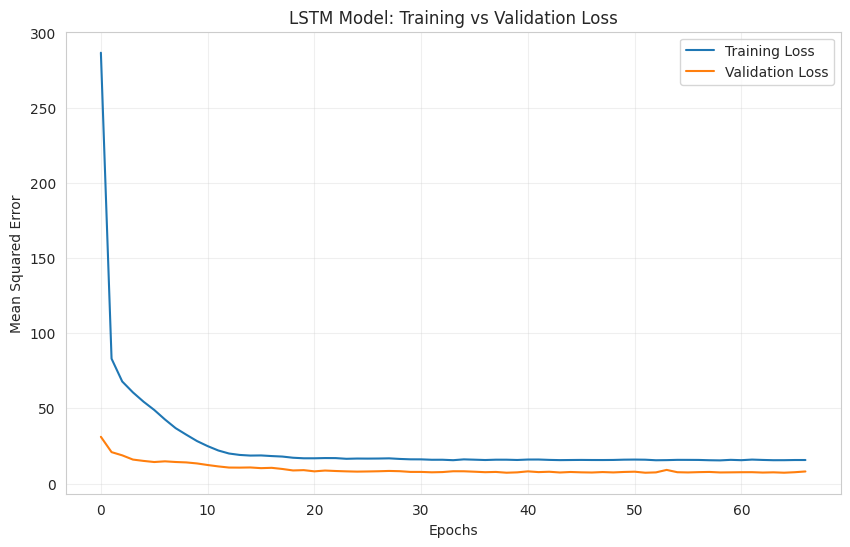

In [ ]:
import matplotlib.pyplot as plt

# Visualize LSTM training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions on the test set using LSTM
y_pred_lstm_final = model.predict(X_test_lstm)

# Evaluate the model
rmse_lstm_final = np.sqrt(mean_squared_error(y_test, y_pred_lstm_final))
mae_lstm_final = mean_absolute_error(y_test, y_pred_lstm_final)
r2_lstm_final = r2_score(y_test, y_pred_lstm_final)

print("LSTM Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm_final:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lstm_final:.4f}")
print(f"R-squared (R2): {r2_lstm_final:.4f}")

406/406 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 2.6119
Mean Absolute Error (MAE): 1.8037
R-squared (R2): 0.9320


### **7. Transformer Model for Regression**

We will now implement a Transformer-based architecture. Transformers use self-attention mechanisms to weigh the significance of different parts of the input data. For this tabular regression task, we treat our 17 principal components as a single sequence of features.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np

tf.random.set_seed(RANDOM_SEED)

# --- 1. Positional Encoding ---
# Transformers have no inherent sequence order; this injects temporal structure
class PositionalEncoding(layers.Layer):
    def call(self, x):
        seq_len = tf.shape(x)[1]
        d_model = x.shape[-1]
        positions = tf.cast(tf.range(seq_len)[:, tf.newaxis], tf.float32)
        dims = tf.cast(tf.range(d_model)[tf.newaxis, :], tf.float32)
        angles = positions / tf.pow(10000.0, (2 * (dims // 2)) / tf.cast(d_model, tf.float32))
        sines = tf.math.sin(angles[:, 0::2])
        cosines = tf.math.cos(angles[:, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)[:, :d_model]
        return x + pos_encoding[tf.newaxis, :, :]

# --- 2. Improved Encoder with Gated FF + Squeeze-Excitation ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Pre-LN (more stable gradients than original post-LN)
    x = layers.LayerNormalization(epsilon=1e-6)(inputs)
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(x, x)
    x = layers.Dropout(dropout)(x)
    res = x + inputs

    # Gated feedforward (GEGLU) — better than plain ReLU for regression
    x = layers.LayerNormalization(epsilon=1e-6)(res)
    gate = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='sigmoid')(x)
    x_ff = layers.Conv1D(filters=ff_dim, kernel_size=1, activation='gelu')(x)
    x = x_ff * gate  # Gating
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)

    # Squeeze-Excitation: recalibrate channel importance
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(inputs.shape[-1] // 4, activation='relu')(se)
    se = layers.Dense(inputs.shape[-1], activation='sigmoid')(se)
    x = x * se[:, tf.newaxis, :]

    return x + res

# --- 3. Multi-Scale Feature Extraction (parallel conv branches) ---
def multi_scale_conv(x):
    branches = []
    for k in [1, 3, 5]:  # Capture short-, mid-, long-range local patterns
        b = layers.Conv1D(filters=x.shape[-1] // 3, kernel_size=k, padding='same', activation='gelu')(x)
        branches.append(b)
    return layers.Concatenate()(branches)

def build_enhanced_transformer(
    input_shape, head_size, num_heads, ff_dim,
    num_transformer_blocks, mlp_units, dropout=0, mlp_dropout=0
):
    inputs = tf.keras.Input(shape=input_shape)

    # Project to model dim + add positional encoding
    x = layers.Conv1D(filters=head_size * num_heads, kernel_size=1)(inputs)
    x = PositionalEncoding()(x)

    # Multi-scale local feature extraction before global attention
    x = multi_scale_conv(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Transformer blocks
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # Dual pooling: captures both mean signal and peak features
    avg = layers.GlobalAveragePooling1D()(x)
    mx  = layers.GlobalMaxPooling1D()(x)
    x = layers.Concatenate()([avg, mx])

    # MLP head with residual skip
    for dim in mlp_units:
        skip = layers.Dense(dim)(x)
        x = layers.Dense(dim, activation='gelu')(x)
        x = layers.LayerNormalization()(x)
        x = layers.Dropout(mlp_dropout)(x)
        x = x + skip  # residual

    outputs = layers.Dense(1)(x)
    return tf.keras.Model(inputs, outputs)

# --- 4. Build ---
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])

transformer_model = build_enhanced_transformer(
    input_shape,
    head_size=64,       # key_dim per head; total model dim = 64*8 = 512
    num_heads=8,
    ff_dim=256,
    num_transformer_blocks=4,
    mlp_units=[256, 128],
    dropout=0.05,
    mlp_dropout=0.05,
)

# --- 5. Cosine Decay LR + Warmup (critical for transformers) ---
total_steps = (len(X_train_lstm) // 32) * 200  # batch_size=32, 200 epochs
warmup_steps = total_steps // 10

lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=3e-4,
    first_decay_steps=total_steps - warmup_steps,
    t_mul=1.0, m_mul=0.9, alpha=1e-5,
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4,   # L2 via AdamW, better than adding kernel_regularizer everywhere
    clipnorm=1.0,        # gradient clipping prevents spikes
)

# --- 6. Huber loss: MSE near zero, MAE for large errors (more robust) ---
transformer_model.compile(
    loss=tf.keras.losses.Huber(delta=1.0),
    optimizer=optimizer,
    metrics=['mae'],
)

transformer_model.summary()
print('\nEnhanced Transformer model built.')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 1, 17)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1, 512)    │      9,216 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 1, 512)    │          0 │ conv1d[0][0]      │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1, 170)    │     87,210 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1, 170)    │    261,290 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1, 170)    │    435,370 │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1, 510)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_2[0][0],   │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 510)    │      1,020 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 510)    │      1,020 │ layer_normalizat… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 510)    │  1,046,526 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1, 510)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 510)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 510)    │      1,020 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 1, 256)    │    130,816 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1, 256)    │    130,816 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 256)    │          0 │ conv1d_5[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 1, 256)    │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 1, 510)    │    131,070 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 510)       │          0 │ conv1d_6[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,669,327 (29.26 MB)

 Trainable params: 7,669,327 (29.26 MB)

 Non-trainable params: 0 (0.00 B)


Enhanced Transformer model built.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Note: ReduceLROnPlateau was removed because the optimizer is already
# controlled by the CosineDecayRestarts schedule defined in the previous cell.
callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss')
]

print("Training Enhanced Transformer Model...")
history_transformer = transformer_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("Enhanced Transformer Model Training Completed.")

Training Enhanced Transformer Model...
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


650/650 ━━━━━━━━━━━━━━━━━━━━ 94s 65ms/step - loss: 3.2436 - mae: 3.7075 - val_loss: 1.2067 - val_mae: 1.6328
Epoch 2/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 1.3280 - mae: 1.7633 - val_loss: 0.9381 - val_mae: 1.3504
Epoch 3/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 1.0771 - mae: 1.5020 - val_loss: 0.9295 - val_mae: 1.3387
Epoch 4/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.8975 - mae: 1.3142 - val_loss: 0.8906 - val_mae: 1.3144
Epoch 5/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.8208 - mae: 1.2321 - val_loss: 0.7229 - val_mae: 1.1195
Epoch 6/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.8003 - mae: 1.2104 - val_loss: 0.6462 - val_mae: 1.0422
Epoch 7/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.7449 - mae: 1.1500 - val_loss: 0.6445 - val_mae: 1.0339
Epoch 8/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.7589 - mae: 1.1668 - val_loss: 0.7872 - val_mae: 1.1890
Epoch 9/300
650/650 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/st

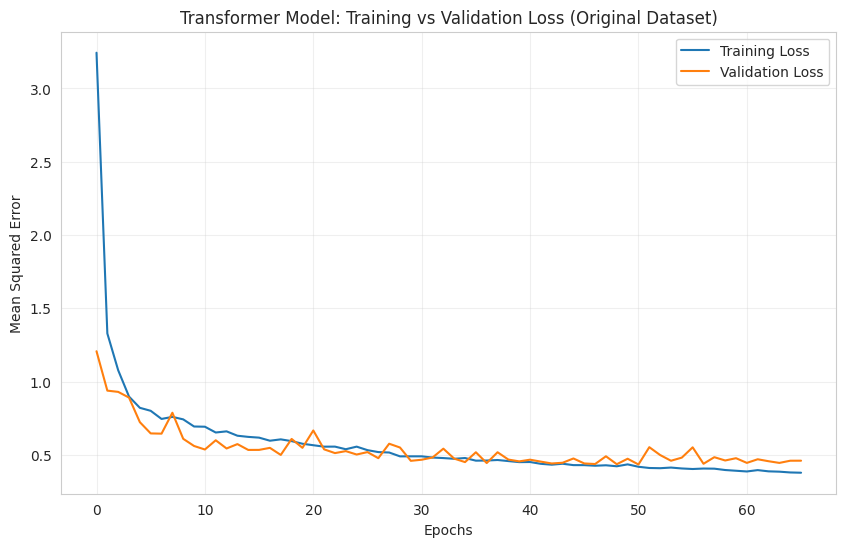

In [ ]:
import matplotlib.pyplot as plt

# Visualize Transformer training history (Original Dataset)
plt.figure(figsize=(10, 6))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')
plt.title('Transformer Model: Training vs Validation Loss (Original Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Make predictions
y_pred_trans = transformer_model.predict(X_test_lstm)

# Evaluate the model
rmse_trans = np.sqrt(mean_squared_error(y_test, y_pred_trans))
mae_trans = mean_absolute_error(y_test, y_pred_trans)
r2_trans = r2_score(y_test, y_pred_trans)

print("Transformer Regressor Model Evaluation Metrics:")
print(f"Root Mean Squared Error (RMSE): {rmse_trans:.4f}")
print(f"Mean Absolute Error (MAE): {mae_trans:.4f}")
print(f"R-squared (R2): {r2_trans:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


406/406 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step
Transformer Regressor Model Evaluation Metrics:
Root Mean Squared Error (RMSE): 1.0939
Mean Absolute Error (MAE): 0.7656
R-squared (R2): 0.9881


### **Model Performance Comparison**

Below is a summary table of the evaluation metrics (RMSE, MAE, and R² Score) for all the baseline models and the Transformer model, trained and evaluated on the original dataset.

In [ ]:
print("Model Performance Comparison Table (Sorted by R2 - Descending):")
display(metrics_df.sort_values(by='R2', ascending=False))

Model Performance Comparison Table (Sorted by R2 - Descending):


,Model,RMSE,MAE,R2
5,Transformer,1.093895,0.765647,0.988074
4,LSTM,2.611934,1.803698,0.932004
2,SVR,4.032811,2.823968,0.837904
3,XGBoost,4.692479,3.647322,0.780537
0,Linear Regression,5.528769,4.361069,0.695342
1,KNN,6.202197,4.920721,0.616605


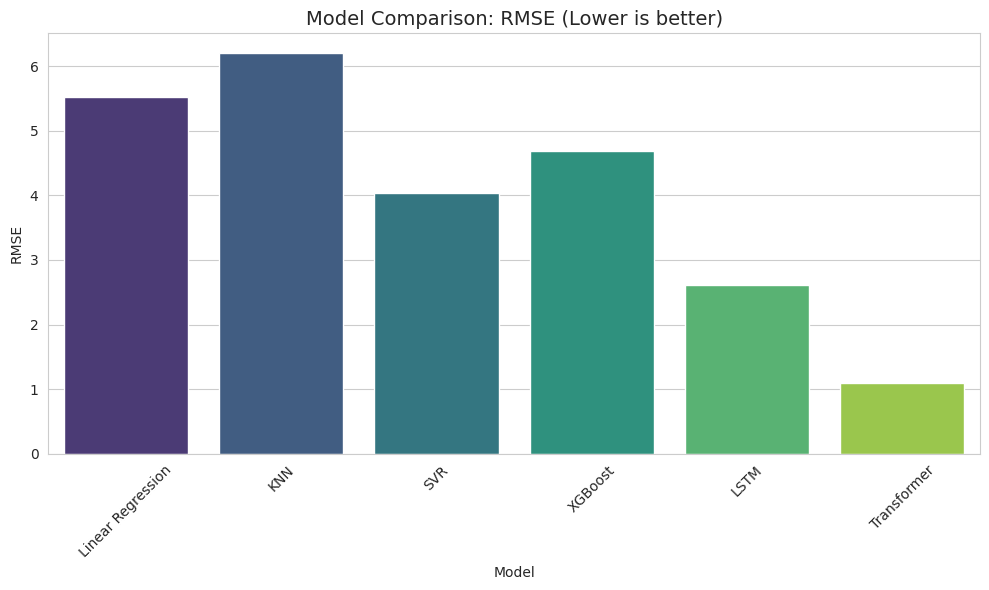

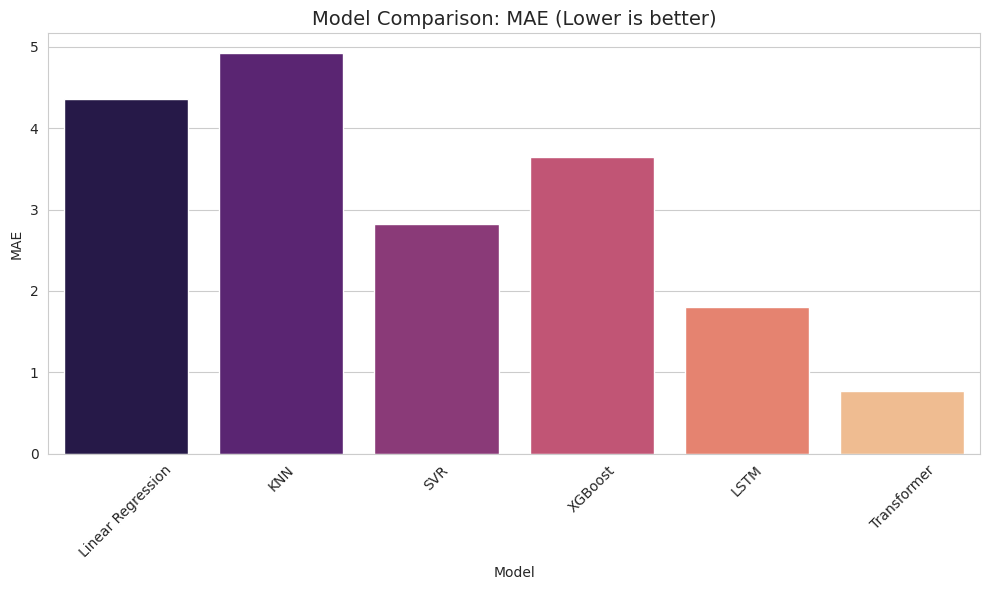

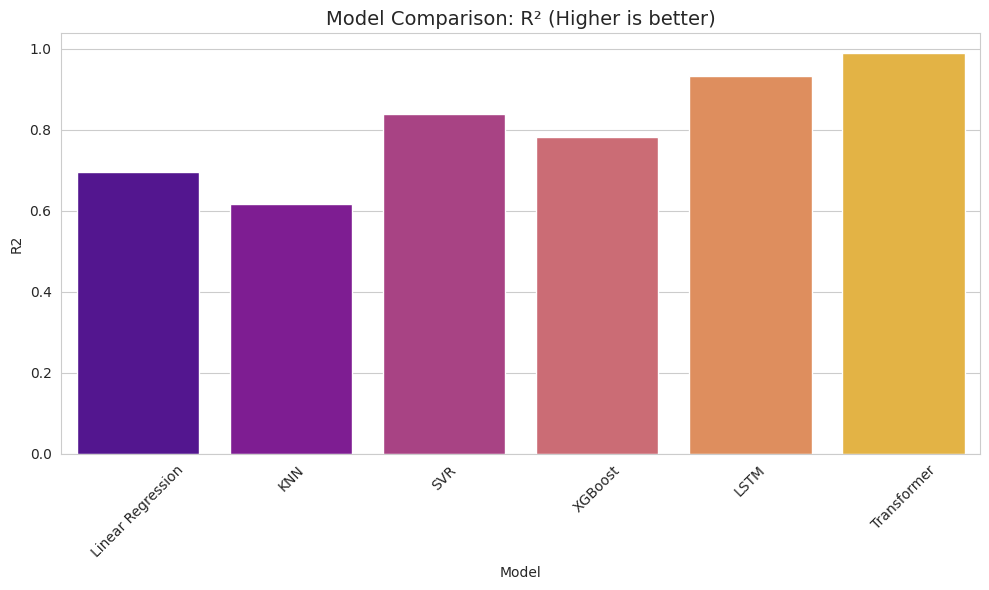

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data preparation
models = ['Linear Regression', 'KNN', 'SVR', 'XGBoost', 'LSTM', 'Transformer']
rmse_vals = [rmse, rmse_knn, rmse_svr, rmse_xgb, rmse_lstm_final, rmse_trans]
mae_vals = [mae, mae_knn, mae_svr, mae_xgb, mae_lstm_final, mae_trans]
r2_vals = [r2, r2_knn, r2_svr, r2_xgb, r2_lstm_final, r2_trans]

metrics_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_vals,
    'MAE': mae_vals,
    'R2': r2_vals
})

sns.set_style("whitegrid")

# 1. Plot RMSE
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='RMSE', data=metrics_df, palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: RMSE (Lower is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Plot MAE
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='MAE', data=metrics_df, palette='magma', hue='Model', legend=False)
plt.title('Model Comparison: MAE (Lower is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Plot R2
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2', data=metrics_df, palette='plasma', hue='Model', legend=False)
plt.title('Model Comparison: R² (Higher is better)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

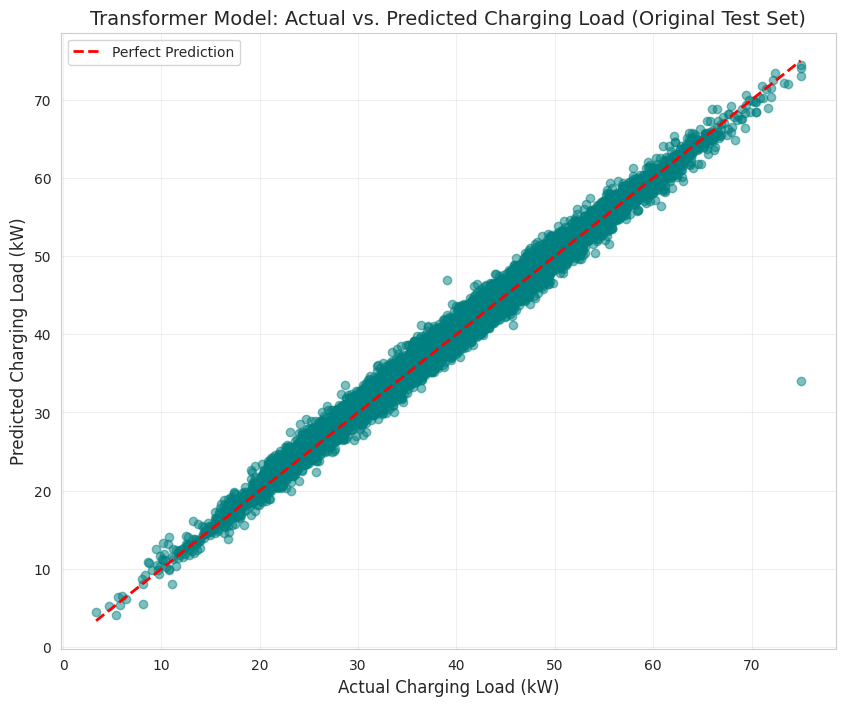

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions for the Transformer model on the original test set
y_pred_trans_flat = y_pred_trans.flatten()

plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_trans_flat, alpha=0.5, color='teal')

# Add a 45-degree line for reference (Perfect Prediction)
max_val = max(y_test.max(), y_pred_trans_flat.max())
min_val = min(y_test.min(), y_pred_trans_flat.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Transformer Model: Actual vs. Predicted Charging Load (Original Test Set)', fontsize=14)
plt.xlabel('Actual Charging Load (kW)', fontsize=12)
plt.ylabel('Predicted Charging Load (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **9. Diagnostic: Comparing Data Distributions**

The evaluation above showed a massive error. Let's compare the distributions of the original training data and the Pakistan synthetic data to identify the mismatch.

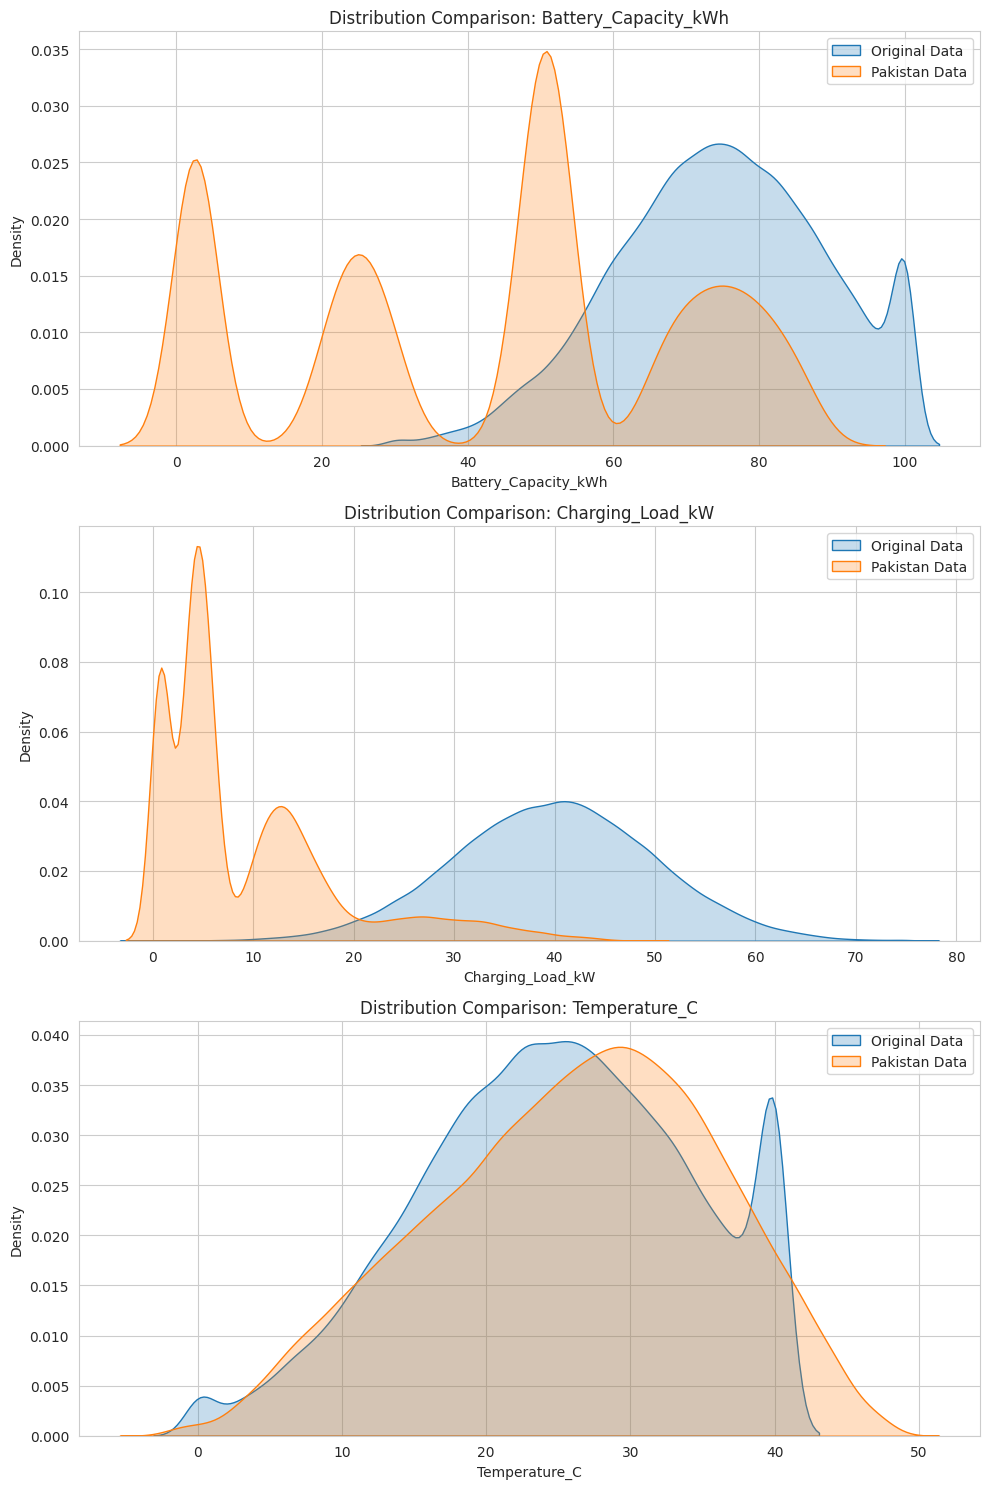

Original Data Stats:


,Battery_Capacity_kWh,Charging_Load_kW,Temperature_C
count,64945.000000,64945.000000,64945.000000
mean,74.725734,39.984615,24.654049
std,14.346408,9.993323,9.409490
min,30.000000,0.000000,0.000000
25%,64.935248,33.247724,18.140208
50%,74.969499,40.027261,24.921663
75%,85.134281,46.702958,31.751901
max,100.000000,75.000000,40.000000



Pakistan Data Stats:


,Battery_Capacity_kWh,Charging_Load_kW,Temperature_C
count,50000.000000,50000.000000,50000.000000
mean,43.009212,9.150581,25.985018
std,26.879599,8.898922,9.872611
min,1.500000,0.400000,-2.000000
25%,22.600000,3.470000,19.000000
50%,49.700000,5.300000,26.800000
75%,67.400000,13.310000,33.400000
max,88.000000,48.300000,48.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to compare
compare_cols = ['Battery_Capacity_kWh', 'Charging_Load_kW', 'Temperature_C']

fig, axes = plt.subplots(len(compare_cols), 1, figsize=(10, 15))

for i, col in enumerate(compare_cols):
    sns.kdeplot(df_cleaned[col], ax=axes[i], label='Original Data', fill=True)
    sns.kdeplot(pakistan_df[col], ax=axes[i], label='Pakistan Data', fill=True)
    axes[i].set_title(f'Distribution Comparison: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Check basic statistics mismatch
print("Original Data Stats:")
display(df_cleaned[compare_cols].describe())

print("\nPakistan Data Stats:")
display(pakistan_df[compare_cols].describe())

### **10. Deeper Investigation: Correlation and Range Analysis**

We need to see if the relationship between features in the Pakistan dataset (generated via Monte Carlo) matches the original data. If the correlations are different, the model's learned weights will not apply.

Correlation with Charging_Load_kW Comparison:


,Pakistan_Corr,Original_Corr
Battery_Capacity_kWh,0.352128,0.000538
Charging_Load_kW,1.000000,1.000000
Charging_Preferences,-0.002270,-0.003339
Charging_Rate_kW,0.987433,0.006026
Charging_Station_ID,NaN,NaN
Current_Latitude,0.002226,0.002604
Current_Longitude,0.002426,0.003298
Destination_Latitude,0.003721,0.002300
Distance_to_Destination_km,0.109644,-0.003784
Energy_Consumption_Rate_kWh/km,0.450789,-0.003870


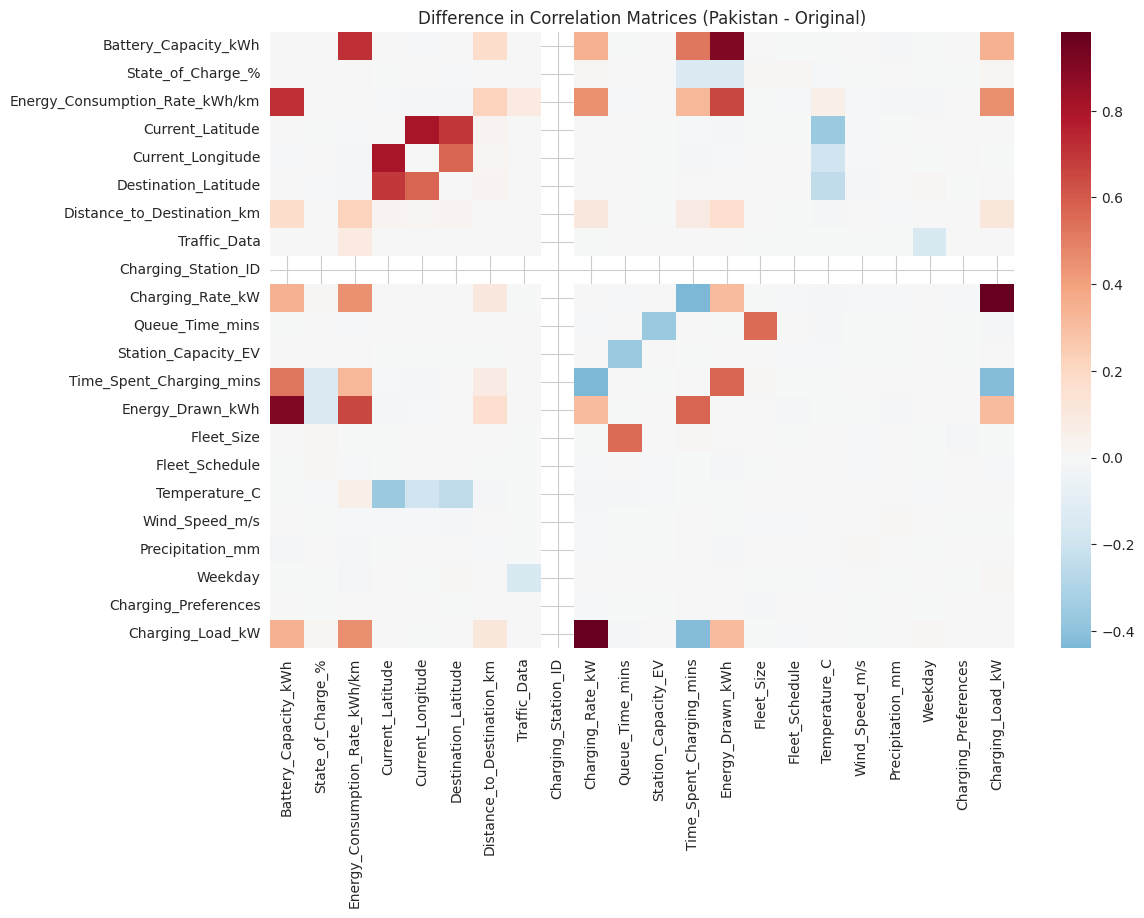

In [ ]:
import numpy as np

# Calculate correlation matrix for Pakistan dataset
pak_corr = pakistan_df[numerical_cols_pca].corr()

# Calculate correlation matrix for Original dataset
orig_corr = df_cleaned[numerical_cols_pca].corr()

# Compare the correlation of features with the target 'Charging_Load_kW'
pak_target_corr = pak_corr['Charging_Load_kW'].sort_values(ascending=False)
orig_target_corr = orig_corr['Charging_Load_kW'].sort_values(ascending=False)

comparison_df = pd.DataFrame({
    'Pakistan_Corr': pak_target_corr,
    'Original_Corr': orig_target_corr
})

print("Correlation with Charging_Load_kW Comparison:")
display(comparison_df)

# Visualization of the difference in correlations
plt.figure(figsize=(12, 8))
sns.heatmap(pak_corr - orig_corr, cmap='RdBu_r', center=0)
plt.title('Difference in Correlation Matrices (Pakistan - Original)')
plt.show()

### **11. Structural Identity Check**

We will now programmatically check if the column names, counts, and data types match between the training data and the Pakistan dataset.

In [ ]:
# Get columns used for PCA from both datasets
train_cols = set(numerical_cols_pca)
pak_cols = set(pakistan_df.columns)

# Check for missing or extra columns
missing_in_pak = train_cols - pak_cols
extra_in_pak = pak_cols - train_cols

print("--- Structural Consistency Check ---")
print(f"Columns missing in Pakistan dataset: {missing_in_pak if missing_in_pak else 'None'}")
print(f"Columns extra in Pakistan dataset: {extra_in_pak if extra_in_pak else 'None'}")

# Check Data Types for shared columns
shared_cols = list(train_cols.intersection(pak_cols))
dtypes_match = df_cleaned[shared_cols].dtypes.equals(pakistan_df[shared_cols].dtypes)

print(f"Data types match for all shared columns: {dtypes_match}")

if not dtypes_match:
    print("\nDatatype Mismatches:")
    for col in shared_cols:
        if df_cleaned[col].dtype != pakistan_df[col].dtype:
            print(f"- {col}: Train ({df_cleaned[col].dtype}) vs Pakistan ({pakistan_df[col].dtype})")

# Verify Shape for Model Feeding
print(f"\nExpected Input Features (PCA): {len(numerical_cols_pca)}")
print(f"Actual Available Features in Pakistan Data: {len(shared_cols)}")

--- Structural Consistency Check ---
Columns missing in Pakistan dataset: None
Columns extra in Pakistan dataset: {'Weather_Conditions', 'Date_Time', 'Vehicle_ID', 'Destination_Longitude', 'Road_Conditions', 'Session_Start_Hour'}
Data types match for all shared columns: True

Expected Input Features (PCA): 22
Actual Available Features in Pakistan Data: 22


### **12. Fine-Tuning the Transformer on Pakistan Data**

To bridge the domain gap, we will use a portion of the Pakistan dataset to fine-tune the Transformer. We will use a small learning rate to avoid destroying the patterns learned from the larger original dataset.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 0. SETUP & CONFIGURATION
# ==========================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Using a distinct, explicit name for your source dataframe
pakistan_load_data_df = pakistan_df.copy()

# ==========================================
# 1. STRICT TRAIN/TEST SPLIT (No Leakage)
# ==========================================
X_raw = pakistan_load_data_df[numerical_cols_pca]
y_raw = pakistan_load_data_df['Charging_Load_kW'].values

# Split FIRST: 10% for fine-tuning, 90% for final evaluation
X_raw_train, X_raw_test, y_pak_train, y_pak_test = train_test_split(
    X_raw, y_raw, test_size=0.9, random_state=RANDOM_SEED
)

print(f"Training features shape (raw): {X_raw_train.shape}")
print(f"Testing features shape (raw): {X_raw_test.shape}")

# ==========================================
# 2. FIT PREPROCESSING ONLY ON TRAINING DATA
# ==========================================
# Fit Scaler on 10% Train
pak_scaler = StandardScaler()
X_train_scaled = pak_scaler.fit_transform(X_raw_train)

# Fit PCA on 10% Train
pak_pca = PCA(n_components=17, random_state=RANDOM_SEED)
X_train_pc = pak_pca.fit_transform(X_train_scaled)

# ==========================================
# 3. TRANSFORM TEST DATA (No Fitting!)
# ==========================================
# Use the trained assets to transform the 90% Test data safely
X_test_scaled = pak_scaler.transform(X_raw_test)
X_test_pc = pak_pca.transform(X_test_scaled)

# ==========================================
# 4. RESHAPE FOR TRANSFORMER (Time Steps = 1)
# ==========================================
# Reshaping to (samples, time_steps, features) -> (N, 1, 17)
X_pak_train = X_train_pc.reshape(X_train_pc.shape[0], 1, X_train_pc.shape[1])
X_pak_test = X_test_pc.reshape(X_test_pc.shape[0], 1, X_test_pc.shape[1])

print(f"\nFinal Transformer Input Shapes:")
print(f"X_pak_train: {X_pak_train.shape} | y_pak_train: {y_pak_train.shape}")
print(f"X_pak_test:  {X_pak_test.shape}  | y_pak_test:  {y_pak_test.shape}")

# ==========================================
# 5. FINE-TUNING THE PRE-TRAINED MODEL
# ==========================================
# Prepare EarlyStopping based on validation split from the training subset
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

# Compile with a conservative learning rate for fine-tuning
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
transformer_model.compile(loss='mse', optimizer=optimizer)

print("\nStarting Domain-Adjusted Fine-tuning (max 200 epochs)... ")
history_finetune = transformer_model.fit(
    X_pak_train,
    y_pak_train,
    validation_split=0.2,  # Uses 20% of the 10% data for internal validation
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nFine-tuning with strict pipeline boundaries and EarlyStopping completed.")

# ==========================================
# 6. EVALUATION ON THE UNSEEN TEST SET (90%)
# ==========================================
print("\nEvaluating fine-tuned model on the untouched 90% Pakistan dataset...")
predictions = transformer_model.predict(X_pak_test).flatten()

Training features shape (raw): (5000, 22)
Testing features shape (raw): (45000, 22)

Final Transformer Input Shapes:
X_pak_train: (5000, 1, 17) | y_pak_train: (5000,)
X_pak_test:  (45000, 1, 17)  | y_pak_test:  (45000,)

Starting Domain-Adjusted Fine-tuning (max 200 epochs)... 
Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


120/125 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 503.2457 - mae: 16.5050

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


125/125 ━━━━━━━━━━━━━━━━━━━━ 48s 58ms/step - loss: 196.3137 - mae: 8.9934 - val_loss: 18.0650 - val_mae: 3.2832
Epoch 2/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 12.8238 - mae: 2.6904 - val_loss: 7.3390 - val_mae: 2.1173
Epoch 3/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.1698 - mae: 1.8767 - val_loss: 4.1584 - val_mae: 1.5714
Epoch 4/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 3.9579 - mae: 1.4998 - val_loss: 2.5042 - val_mae: 1.1733
Epoch 5/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9221 - mae: 1.2899 - val_loss: 2.0250 - val_mae: 1.0799
Epoch 6/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.4231 - mae: 1.1715 - val_loss: 1.7435 - val_mae: 0.9750
Epoch 7/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1045 - mae: 1.0911 - val_loss: 1.6866 - val_mae: 0.9715
Epoch 8/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.7726 - mae: 1.0152 - val_loss: 1.5039 - val_mae: 0.9061
Epoch 9/200
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15m

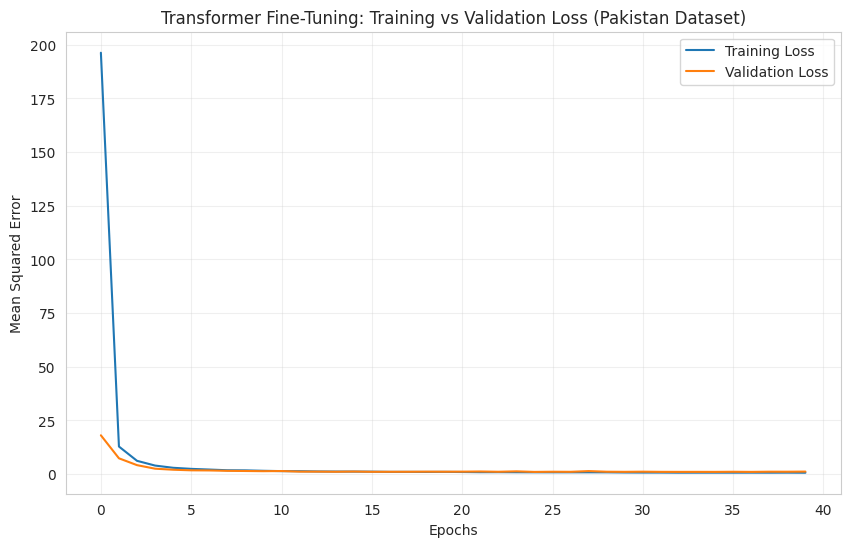

In [ ]:
import matplotlib.pyplot as plt

# Visualize Transformer fine-tuning history (Pakistan Dataset)
plt.figure(figsize=(10, 6))
plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Transformer Fine-Tuning: Training vs Validation Loss (Pakistan Dataset)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **13. Final Evaluation after Fine-Tuning**

Now we evaluate the performance on the remaining 90% of the Pakistan dataset that the model has not seen during the fine-tuning stage.

In [ ]:
# 1. Predict on the Pakistan test set
y_pred_pak_final = transformer_model.predict(X_pak_test)

# 2. Evaluate metrics
rmse_pak_final = np.sqrt(mean_squared_error(y_pak_test, y_pred_pak_final))
mae_pak_final = mean_absolute_error(y_pak_test, y_pred_pak_final)
r2_pak_final = r2_score(y_pak_test, y_pred_pak_final)

print("--- Metrics on Pakistan Data AFTER Fine-Tuning ---")
print(f"Root Mean Squared Error (RMSE): {rmse_pak_final:.4f}")
print(f"Mean Absolute Error (MAE): {mae_pak_final:.4f}")
print(f"R-squared (R2): {r2_pak_final:.4f}")

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
--- Metrics on Pakistan Data AFTER Fine-Tuning ---
Root Mean Squared Error (RMSE): 1.0950
Mean Absolute Error (MAE): 0.7500
R-squared (R2): 0.9849


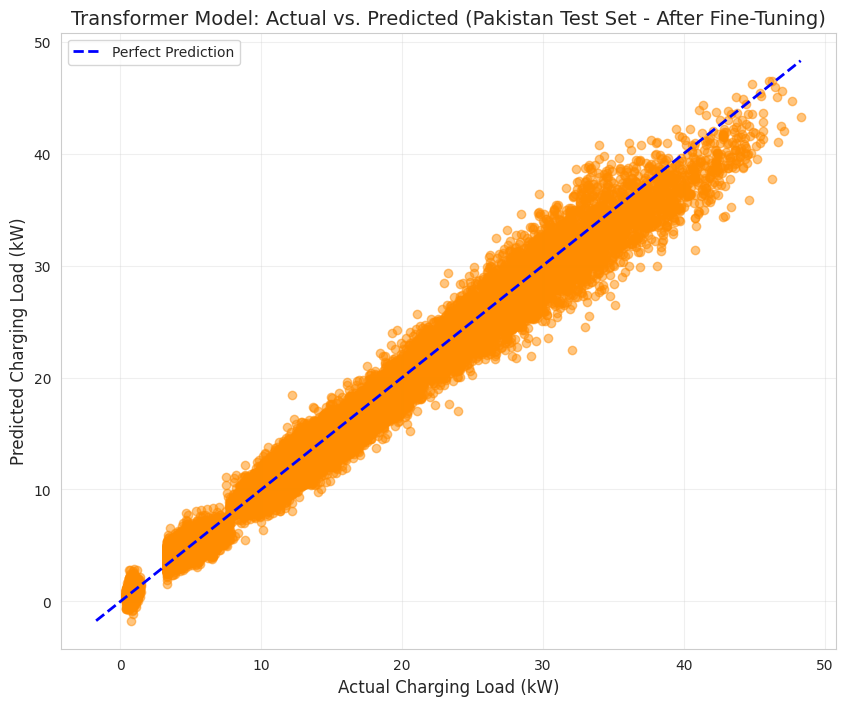

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate predictions for the Transformer model on the Pakistan test set
y_pred_pak_flat = y_pred_pak_final.flatten()

plt.figure(figsize=(10, 8))
plt.scatter(y_pak_test, y_pred_pak_flat, alpha=0.5, color='darkorange')

# Add a 45-degree line for reference (Perfect Prediction)
max_val = max(y_pak_test.max(), y_pred_pak_flat.max())
min_val = min(y_pak_test.min(), y_pred_pak_flat.min())
plt.plot([min_val, max_val], [min_val, max_val], color='blue', linestyle='--', lw=2, label='Perfect Prediction')

plt.title('Transformer Model: Actual vs. Predicted (Pakistan Test Set - After Fine-Tuning)', fontsize=14)
plt.xlabel('Actual Charging Load (kW)', fontsize=12)
plt.ylabel('Predicted Charging Load (kW)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### **14. Domain Transfer Comparison: Transformer Performance Scenario Analysis**

We will now visualize the performance of the Transformer model across three distinct scenarios:
1.  **Original Test Set:** Performance on the dataset it was originally trained on.
2.  **Pakistan Zero-Shot:** Performance on the Pakistan dataset using the original weights and scaling (resulting in high error).
3.  **Pakistan Fine-Tuned:** Performance on the Pakistan dataset after domain-specific scaling and fine-tuning.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data for scenario comparison
scenario_data = {
    'Scenario': ['Original', 'Pakistan Fine-Tuned'],
    'RMSE': [rmse_trans, rmse_pak_final],
    'MAE': [mae_trans, mae_pak_final],
    'R2': [r2_trans, r2_pak_final]
}

comparison_df = pd.DataFrame(scenario_data)

print("\n\n\nFinal Performance Comparison Table:")
display(comparison_df)





Final Performance Comparison Table:


,Scenario,RMSE,MAE,R2
0,Original,1.093895,0.765647,0.988074
1,Pakistan Fine-Tuned,1.094995,0.750047,0.984857


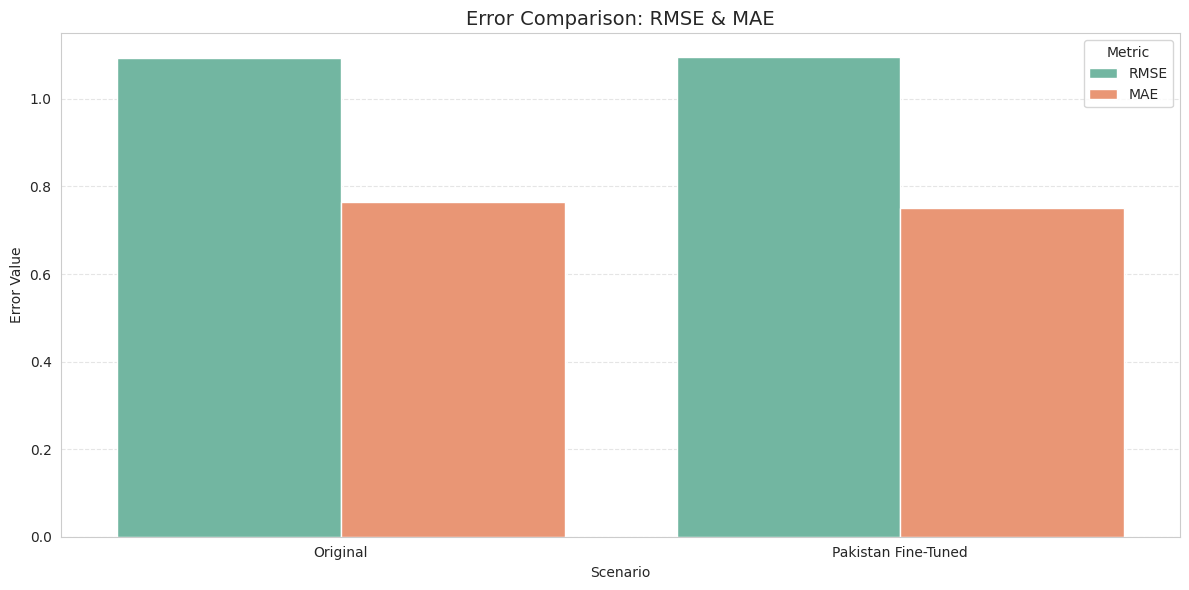

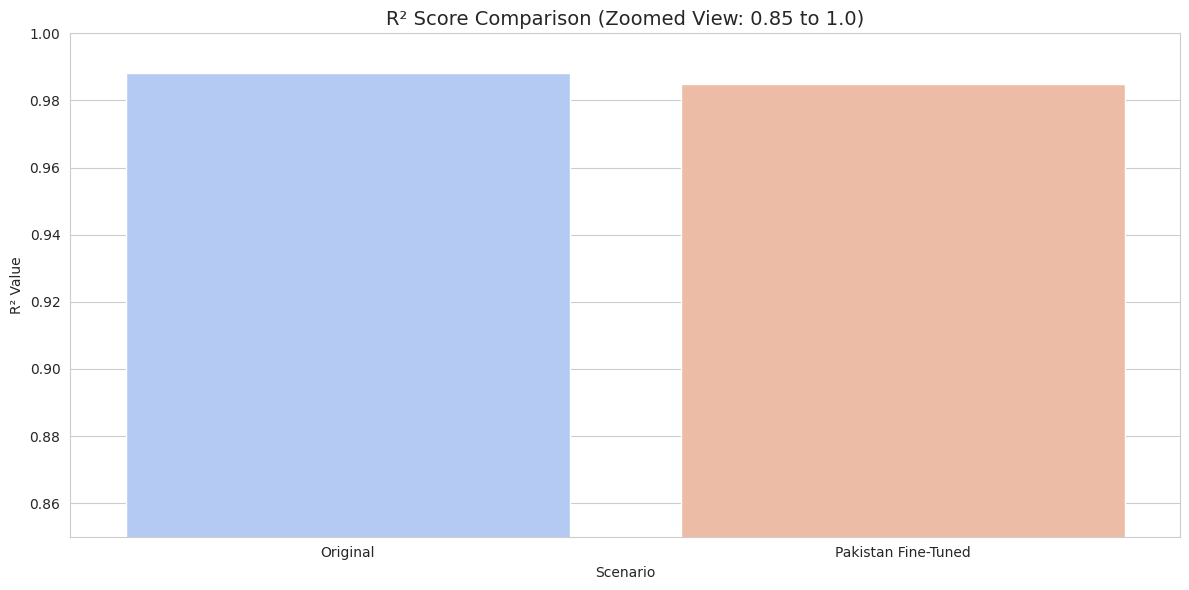

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot RMSE and MAE
plot_df = comparison_df.melt(id_vars='Scenario', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Value')

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
sns.barplot(x='Scenario', y='Value', hue='Metric', data=plot_df, palette='Set2')
plt.title('Error Comparison: RMSE & MAE', fontsize=14)
plt.ylabel('Error Value')
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Plot R2 Score (Zoomed View)
plt.figure(figsize=(12, 6))
# Fix: Use the original comparison_df and map x and y correctly
sns.barplot(x='Scenario', y='R2', data=comparison_df, palette='coolwarm', hue='Scenario', legend=False)
plt.title('R² Score Comparison (Zoomed View: 0.85 to 1.0)', fontsize=14)
plt.ylabel('R² Value')
# Adjusting limits to encompass both scores (0.88 and 0.98)
plt.ylim(0.85, 1.0)
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()